<a href="https://colab.research.google.com/github/Prabal03842/New-Model/blob/main/New_All_Plastic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===============================================================
# PART 1 — Imports, Global Settings, Polymer Sets, Data Structures
# ===============================================================

# ---------------------------
# 1. Import Required Libraries
# ---------------------------

import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# For evolutionary optimisation
import random
import time
from copy import deepcopy

# Display settings
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.dpi'] = 200


# -----------------------------------
# 2. Define Polymer Sets and Segments
# -----------------------------------

POLYMERS = ["PET", "HDPE", "LDPE", "PP", "PS", "PVC", "FLEX"]
SEGMENTS = ["pack"]
ROUTES = ["mech", "chem", "energy", "landfill", "mis"]


# --------------------------------------------------
# 3. Create Parameter Dictionaries
# --------------------------------------------------

a = {}
b = {}
delta = {}
alpha = {}

phi_V = {}
phi_R = {}
theta = {}

y_mech = {}
y_chem = {}
omega = {}

C_V = {}
C_R_mech = {}
C_R_chem = {}
C_F = {}

H_V = {}
H_R = {}
H_F = {}

TC_prod = {}
TC_waste = {}

C_G = {}
EPR_fee = {}

EF_V = {}
EF_R_mech = {}
EF_R_chem = {}
EF_energy = {}
EF_landfill = {}
EF_transport = {}

eta = {}

s = {}

# -----------------------------
# GLOBAL PARAMETERS
# -----------------------------
P_carbon = 0.0
G_budget = 150000
Omega_PB = 1e12
Omega_PB_risk = 1e12


# ---------------------------------------------------------
# 4. SAFETY INITIALISATION (Prevents KeyErrors)
# ---------------------------------------------------------
# These values will be overwritten later IF you provide real data.

for i in POLYMERS:

    # ---------------- Demand parameters ----------------
    for k in SEGMENTS:
        a[(i, k)] = 20000
        b[(i, k)] = 2000
        delta[(i, k)] = 500
        s[(i, k)] = 1.0
        theta[(i, k)] = 0.05
        C_F[(i, k)] = 0.2
        H_F[(i, k)] = 0.01

    # ---------------- Recycling & waste ----------------
    y_mech[i] = 0.75
    y_chem[i] = 0.55
    omega[i] = 0.10

    # ---------------- Emission factors ----------------
    EF_V[i] = 2.0
    EF_R_mech[i] = 0.3
    EF_R_chem[i] = 0.8
    EF_energy[i] = 1.2
    EF_landfill[i] = 0.6
    EF_transport[i] = 0.05

    # ---------------- Costs ----------------
    C_V[i] = 1.5
    C_R_mech[i] = 0.4
    C_R_chem[i] = 0.9
    H_V[i] = 0.02
    H_R[i] = 0.03
    TC_prod[i] = 0.1
    TC_waste[i] = 0.05
    C_G[i] = 0.002
    EPR_fee[i] = 0.01

    # ---------------- Others ----------------
    alpha[i] = 0.001
    phi_V[i] = 0.08
    phi_R[i] = 0.10
    eta[i] = 1.0


# ---------------------------------------------------------
# 5. Helper: Pretty-print tables
# ---------------------------------------------------------

def print_polymer_table(title, dictionary):
    print(f"\n=== {title} ===")
    df = pd.DataFrame.from_dict(dictionary, orient="index", columns=["Value"])
    display(df)


def print_polymer_segment_table(title, dictionary):
    print(f"\n=== {title} ===")
    rows = []
    for i in POLYMERS:
        for k in SEGMENTS:
            rows.append([i, k, dictionary.get((i, k), None)])
    df = pd.DataFrame(rows, columns=["Polymer", "Segment", "Value"])
    display(df)


# ---------------------------------------------------------
# 6. Decision Variable Template (used in Part 3)
# ---------------------------------------------------------

def empty_solution_vector():
    sol = {}
    for i in POLYMERS:
        sol[i] = {
            "price": None,
            "G": None,
            "r": None,

            "x_mech": None,
            "x_chem": None,
            "x_energy": None,
            "x_landfill": None,
            "x_mis": None,

            "P_V": None,
            "T_F": None,
            "tau": None,
        }
    return sol


print("PART 1 successfully loaded — all dictionaries initialised — NO KeyErrors will occur in Part 2 / 3 / 4.")



PART 1 successfully loaded — all dictionaries initialised — NO KeyErrors will occur in Part 2 / 3 / 4.


In [ ]:
# ===============================================================
# PART 2 — Mathematical Model (Demand, Flows, Costs, Emissions)
# ===============================================================

import numpy as np

# ----------------------------------------------
# Helper: safe access to parameter dictionaries
# ----------------------------------------------
def require_key(d, key, name):
    """Raise clean error if dictionary key is missing."""
    if key not in d:
        raise KeyError(f"[ERROR] Missing key {key} in parameter dictionary '{name}'.")
    return d[key]


# -----------------------------------------------------
# 1. Demand Function  D_{i,k} = a - b p + δ (1 - e^{-α G})
# -----------------------------------------------------
def demand(i, k, price, G):

    A  = require_key(a,     (i, k), "a[(i,k)]")
    B  = require_key(b,     (i, k), "b[(i,k)]")
    D0 = require_key(delta, (i, k), "delta[(i,k)]")
    AL = require_key(alpha, i,      "alpha[i]")

    return A - B * price + D0 * (1 - np.exp(-AL * G))


# -------------------------------------------
# 2. Total polymer demand D_i = sum over k
# -------------------------------------------
def total_demand(i, solution):
    return sum(
        demand(i, k, solution[i]["price"], solution[i]["G"])
        for k in SEGMENTS
    )


# ----------------------------------------------------
# 3. Waste Generation: W_i = ω_i * D_i
# ----------------------------------------------------
def waste_generated(i, solution):

    om = require_key(omega, i, "omega[i]")
    return om * total_demand(i, solution)


# ----------------------------------------------------------------
# 4. Routing Fractions and Waste Allocations W_i^r = x_i^r * W_i
# ----------------------------------------------------------------
def waste_routing(i, solution):

    W = waste_generated(i, solution)
    x = solution[i]

    return {
        "mech":     x["x_mech"]     * W,
        "chem":     x["x_chem"]     * W,
        "energy":   x["x_energy"]   * W,
        "landfill": x["x_landfill"] * W,
        "mis":      x["x_mis"]      * W,
    }


# ----------------------------------------------------------
# 5. Recycling Output: Q_i^R = y_mech*W_mech + y_chem*W_chem
# ----------------------------------------------------------
def recycled_output(i, solution):

    ym = require_key(y_mech, i, "y_mech[i]")
    yc = require_key(y_chem, i, "y_chem[i]")

    W = waste_routing(i, solution)
    return ym * W["mech"] + yc * W["chem"]


# -----------------------------------------------------------------------
# 6. Resin Usage U_i^V and U_i^R using r_{i,k} and resin requirement s_{i,k}
# -----------------------------------------------------------------------
def resin_usage(i, solution):

    r_i = solution[i]["r"]
    total_V = 0
    total_R = 0

    for k in SEGMENTS:
        P_F = demand(i, k, solution[i]["price"], solution[i]["G"])

        sk = require_key(s, (i, k), "s[(i,k)]")

        total_V += sk * (1 - r_i) * P_F
        total_R += sk * r_i * P_F

    return total_V, total_R


# ---------------------------------------------------------------------------------
# 7. Virgin Resin Steady-State Inventory
# ---------------------------------------------------------------------------------
def virgin_inventory_ss(i, solution):

    phi = require_key(phi_V, i, "phi_V[i]")
    P_V = solution[i]["P_V"]
    U_V, _ = resin_usage(i, solution)

    return (P_V - U_V) / phi


# ---------------------------------------------------------------------------------
# 8. Recycled Resin Steady-State Inventory
# ---------------------------------------------------------------------------------
def recycled_inventory_ss(i, solution):

    phi = require_key(phi_R, i, "phi_R[i]")
    Q_R = recycled_output(i, solution)
    _, U_R = resin_usage(i, solution)

    return (Q_R - U_R) / phi


# =============================================================================
# 9. EPQ FINISHED INVENTORY (Phase I + II integrals EXACT)
# =============================================================================
def F_phase1(t, P_F, D, theta):
    return (P_F - D) / theta * (1 - np.exp(-theta * t))


def F_phase2(t, Fmax, D, theta, tau):
    return np.exp(-theta * (t - tau)) * Fmax - (D / theta) * (1 - np.exp(-theta * (t - tau)))


def finished_inventory_average(i, k, solution):

    theta_ik = require_key(theta, (i, k), "theta[(i,k)]")

    price = solution[i]["price"]
    G     = solution[i]["G"]
    P_F = demand(i, k, price, G)
    D = P_F

    tau = solution[i]["tau"]
    T_F = solution[i]["T_F"]

    # Phase I peak inventory
    Fmax = (P_F - D) / theta_ik * (1 - np.exp(-theta_ik * tau))

    # Phase I integral
    I1 = ((P_F - D) / theta_ik) * (
        tau - (1 - np.exp(-theta_ik * tau)) / theta_ik
    )

    # Phase II integral
    t2 = T_F - tau
    I2 = (
        Fmax * (1 - np.exp(-theta_ik * t2)) / theta_ik
        - (D / theta_ik) * (t2 - (1 - np.exp(-theta_ik * t2)) / theta_ik)
    )

    return (I1 + I2) / T_F


# ============================================
# 10. TOTAL COST MODEL C_tot
# ============================================
def total_cost(solution):

    C_prodV = C_rec_mech = C_rec_chem = 0
    C_manuf = C_hold    = C_trans     = 0
    C_green = C_epr     = 0
    total_emis = 0

    for i in POLYMERS:

        # demand
        D_i = total_demand(i, solution)

        # production cost
        C_prodV += require_key(C_V, i, "C_V[i]") * solution[i]["P_V"]

        # recycling
        W = waste_routing(i, solution)
        C_rec_mech += require_key(C_R_mech, i, "C_R_mech[i]") * W["mech"]
        C_rec_chem += require_key(C_R_chem, i, "C_R_chem[i]") * W["chem"]

        # manufacturing
        for k in SEGMENTS:
            CF = require_key(C_F, (i, k), "C_F[(i,k)]")
            P_F = demand(i, k, solution[i]["price"], solution[i]["G"])
            C_manuf += CF * P_F

        # inventory
        V_ss = virgin_inventory_ss(i, solution)
        R_ss = recycled_inventory_ss(i, solution)

        C_hold += require_key(H_V, i, "H_V[i]") * V_ss
        C_hold += require_key(H_R, i, "H_R[i]") * R_ss

        for k in SEGMENTS:
            HF = require_key(H_F, (i, k), "H_F[(i,k)]")
            F_avg = finished_inventory_average(i, k, solution)
            C_hold += HF * F_avg

        # transport
        Q_R = recycled_output(i, solution)
        C_trans += require_key(TC_prod, i, "TC_prod[i]") * (solution[i]["P_V"] + Q_R)
        C_trans += require_key(TC_waste, i, "TC_waste[i]") * waste_generated(i, solution)

        # green investment
        C_green += require_key(C_G, i, "C_G[i]") * solution[i]["G"]

        # EPR
        C_epr += require_key(EPR_fee, i, "EPR_fee[i]") * D_i

        # emissions
        total_emis += total_emission_polymer(i, solution)

    # carbon pricing
    return (
        C_prodV + C_rec_mech + C_rec_chem +
        C_manuf + C_hold + C_trans +
        C_green + C_epr +
        P_carbon * total_emis
    )


# ====================================================
# 11. EMISSION MODEL
# ====================================================
def total_emission_polymer(i, solution):

    AL = require_key(alpha, i, "alpha[i]")

    P_V = solution[i]["P_V"]
    W   = waste_routing(i, solution)
    Q_R = recycled_output(i, solution)
    G_i = solution[i]["G"]

    emis = 0

    emis += require_key(EF_V, i, "EF_V[i]") * np.exp(-AL * G_i) * P_V
    emis += require_key(EF_R_mech, i, "EF_R_mech[i]") * np.exp(-AL * G_i) * W["mech"]
    emis += require_key(EF_R_chem, i, "EF_R_chem[i]") * np.exp(-AL * G_i) * W["chem"]

    emis += require_key(EF_energy, i, "EF_energy[i]")     * W["energy"]
    emis += require_key(EF_landfill, i, "EF_landfill[i]") * W["landfill"]
    emis += require_key(EF_transport, i, "EF_transport[i]") * (P_V + Q_R + waste_generated(i, solution))

    return emis


def total_emissions(solution):
    return sum(total_emission_polymer(i, solution) for i in POLYMERS)


# ====================================================
# 12. MISMANAGED WASTE & CIRCULARITY
# ====================================================
def mismanaged_total(solution):
    return sum(waste_routing(i, solution)["mis"] for i in POLYMERS)


def mismanaged_risk(solution):
    return sum(
        require_key(eta, i, "eta[i]") * waste_routing(i, solution)["mis"]
        for i in POLYMERS
    )


def circularity_index(solution):
    num = sum(recycled_output(i, solution) for i in POLYMERS)
    den = sum(waste_generated(i, solution) for i in POLYMERS)
    return num / den if den > 0 else 0


# ====================================================
# 13. Full Objective Vector (Z1 = cost, Z2 = emissions, Z3 = leakage)
# ====================================================
def compute_objectives(solution):
    return (
        total_cost(solution),
        total_emissions(solution),
        mismanaged_total(solution),
    )


print("PART 2 loaded successfully — ALL indexing fixed — Zero KeyErrors.")




PART 2 loaded successfully — ALL indexing fixed — Zero KeyErrors.


In [ ]:
# ===============================================================
# PART 3 — DECISION ENCODING, INITIALIZATION, REPAIR OPERATORS
# ===============================================================

import numpy as np

# ===============================================================
# 1. DECISION VECTOR STRUCTURE (per polymer)
# ===============================================================
# For each polymer i, we store:
#   P_V           virgin production rate
#   G             green investment
#   price         selling price
#   r             recycled-content fraction
#   tau           production-phase duration (EPQ)
#   T_F           full EPQ cycle length
#   x_mech        waste → mechanical recycling
#   x_chem        waste → chemical recycling
#   x_energy      waste → energy recovery
#   x_landfill    waste → landfill
#   x_mis         waste → mismanaged

decision_template = {
    "P_V": None,
    "G": None,
    "price": None,
    "r": None,
    "tau": None,
    "T_F": None,
    "x_mech": None,
    "x_chem": None,
    "x_energy": None,
    "x_landfill": None,
    "x_mis": None,
}

# ===============================================================
# 2. VARIABLE BOUNDS
# ===============================================================
# These are generic illustrative bounds. You can tune them later
# to match your numerical illustration more closely.

bounds = {
    "P_V": (0.0, 50000.0),
    "G": (0.0, 50000.0),
    "price": (0.2, 5.0),
    "r": (0.0, 1.0),
    "tau": (0.1, 10.0),
    "T_F": (1.0, 20.0),
    "x_mech": (0.0, 1.0),
    "x_chem": (0.0, 1.0),
    "x_energy": (0.0, 1.0),
    "x_landfill": (0.0, 1.0),
    "x_mis": (0.0, 1.0),
}

# Global system-level bounds (consistent with model)
GREEN_BUDGET = 150000.0   # ∑ G_i ≤ GREEN_BUDGET
PB_LIMIT = 5000.0         # planetary-boundary cap on mismanaged plastic (optional)


# ===============================================================
# 3. NORMALIZE ROUTING FRACTIONS (sum = 1)
# ===============================================================
def normalize_routing(poly):
    routing = [
        poly["x_mech"],
        poly["x_chem"],
        poly["x_energy"],
        poly["x_landfill"],
        poly["x_mis"],
    ]
    total = sum(routing)

    if total <= 0.0 or not np.isfinite(total):
        # Degenerate case → reset to equal routing
        routing = [0.2] * 5
        total = 1.0

    poly["x_mech"], poly["x_chem"], poly["x_energy"], poly["x_landfill"], poly["x_mis"] = [
        r / total for r in routing
    ]


# ===============================================================
# 4. APPLY VARIABLE BOUNDS (per polymer)
# ===============================================================
def apply_bounds(poly):
    for key in poly:
        low, high = bounds[key]
        val = poly[key]
        if val is None or not np.isfinite(val):
            # If uninitialized or NaN → put at mid of bounds
            poly[key] = 0.5 * (low + high)
        else:
            poly[key] = min(max(val, low), high)

    # Simple EPQ feasibility: enforce tau ≤ T_F
    if poly["tau"] > poly["T_F"]:
        poly["tau"] = 0.8 * poly["T_F"]


# ===============================================================
# 5. DIRICHLET INITIALIZATION FOR ROUTING FRACTIONS
# ===============================================================
def sample_routing():
    # Equal-prior Dirichlet → random partition of 1 into 5 parts
    r = np.random.dirichlet([1, 1, 1, 1, 1])
    return {
        "x_mech": float(r[0]),
        "x_chem": float(r[1]),
        "x_energy": float(r[2]),
        "x_landfill": float(r[3]),
        "x_mis": float(r[4]),
    }


# ===============================================================
# 6. CREATE ONE RANDOM POLYMER DECISION BLOCK
# ===============================================================
def random_polymer_decision():
    d = {}

    # Continuous variables sampled uniformly within bounds:
    for key in ["P_V", "G", "price", "r", "tau", "T_F"]:
        low, high = bounds[key]
        d[key] = float(np.random.uniform(low, high))

    # Routing fractions from Dirichlet
    d.update(sample_routing())

    # Apply EPQ relation tau ≤ T_F
    if d["tau"] > d["T_F"]:
        d["tau"] = 0.8 * d["T_F"]

    return d


# ===============================================================
# 7. INITIALIZE THE FULL DECISION VECTOR (ALL POLYMERS)
# ===============================================================
def initialize_solution():
    sol = {}
    for i in POLYMERS:
        sol[i] = random_polymer_decision()

    # Main repair (bounds, routing, green budget, leakage cap)
    sol = leakage_aware_repair(sol)
    return sol


# ===============================================================
# 8. REPAIR: GREEN INVESTMENT BUDGET ∑ G_i ≤ GREEN_BUDGET
# ===============================================================
def green_budget_repair(solution):
    total_G = sum(solution[i]["G"] for i in POLYMERS)

    if total_G > GREEN_BUDGET:
        scaling = GREEN_BUDGET / total_G
        for i in POLYMERS:
            solution[i]["G"] *= scaling

    return solution


# ===============================================================
# 9. REPAIR: MISMANAGED WASTE CAP (PLANETARY BOUNDARY)
# ===============================================================
def leakage_cap_repair(solution):
    """
    If mismanaged_total(solution) > PB_LIMIT, reduce x_mis proportionally
    for all polymers and redistribute the removed share toward mech/chem
    in proportion to yields y_mech, y_chem.
    """
    M_total = mismanaged_total(solution)

    if M_total <= PB_LIMIT:
        return solution

    scaling = PB_LIMIT / M_total

    for i in POLYMERS:
        # Current waste and routing
        W = waste_generated(i, solution)
        poly = solution[i]

        if W <= 0:
            # No waste → nothing to do
            continue

        # Store original mismanaged share before scaling
        x_mis_orig = poly["x_mis"]

        # Scale down mismanaged fraction
        poly["x_mis"] = x_mis_orig * scaling

        # Fraction of mismanaged routing removed
        frac_removed = x_mis_orig - poly["x_mis"]
        if frac_removed <= 0:
            continue

        # Amount of waste (mass) corresponding to removed mismanaged share
        redistribution_mass = W * frac_removed

        # Redistribute mass toward mech & chem, based on yields
        total_y = y_mech[i] + y_chem[i]

        if total_y > 0:
            # Convert mass back to routing fractions
            poly["x_mech"] += (redistribution_mass * (y_mech[i] / total_y)) / W
            poly["x_chem"] += (redistribution_mass * (y_chem[i] / total_y)) / W
        else:
            # If yields zero → send removed portion to landfill
            poly["x_landfill"] += frac_removed

        # Re-normalize routing to keep sum=1 and keep within [0,1]
        normalize_routing(poly)

    return solution


# ===============================================================
# 10. REPAIR: VARIABLE BOUNDS + ROUTING NORMALIZATION
# ===============================================================
def basic_repair(solution):
    for i in POLYMERS:
        poly = solution[i]
        apply_bounds(poly)
        normalize_routing(poly)
    return solution


# ===============================================================
# 11. FULL LEAKAGE-AWARE REPAIR OPERATOR (MAIN REPAIR)
# ===============================================================
def leakage_aware_repair(solution):
    """
    Implements the repair operator described in MP-NSGA-II section:
    1. Apply bounds + EPQ feasibility
    2. Normalise routing (sum = 1)
    3. Enforce green-investment budget
    4. Enforce planetary-boundary leakage cap
    """
    solution = basic_repair(solution)
    solution = green_budget_repair(solution)
    solution = leakage_cap_repair(solution)
    return solution


# ===============================================================
# 12. FEASIBILITY CHECK
# ===============================================================
def is_feasible(solution):
    # Check routing allocations sum to 1 per polymer
    for i in POLYMERS:
        poly = solution[i]
        alloc_sum = (
            poly["x_mech"]
            + poly["x_chem"]
            + poly["x_energy"]
            + poly["x_landfill"]
            + poly["x_mis"]
        )
        if not np.isfinite(alloc_sum) or abs(alloc_sum - 1.0) > 1e-6:
            return False

    # Green budget
    if sum(solution[i]["G"] for i in POLYMERS) > GREEN_BUDGET + 1e-6:
        return False

    # Planetary boundary on mismanaged waste
    if mismanaged_total(solution) > PB_LIMIT + 1e-6:
        return False

    return True


print("PART 3 loaded successfully. Decision encoding and repair operators READY (string-key safe).")



PART 3 loaded successfully. Decision encoding and repair operators READY (string-key safe).


In [ ]:
# ===============================================================
# PART 4 — MP-NSGA-II OPERATORS AND MAIN ALGORITHM
# ===============================================================

import numpy as np
import copy

# ---------------------------------------------------------------
# Hyperparameters (you can tune these later)
# ---------------------------------------------------------------
POP_SIZE   = 80
N_GEN      = 150
P_CROSS    = 0.9       # crossover probability
ETA_C      = 15.0      # SBX crossover distribution index
ETA_M      = 20.0      # Polynomial mutation distribution index
P_MUT_MIN  = 0.05      # minimum mutation prob (adaptive)
P_MUT_MAX  = 0.35      # maximum mutation prob (adaptive)
TOURN_SIZE = 2         # binary tournament


# ===============================================================
# 1. OBJECTIVE EVALUATION (tied directly to Part 2)
# ===============================================================
def evaluate_solution(solution):
    """
    Returns (C_tot, E_tot, M_tot) for a given solution.

    Uses:
      - total_cost(solution)
      - total_emissions(solution)
      - mismanaged_total(solution)
    as defined in Part 2.
    """
    cost = total_cost(solution)
    emis = total_emissions(solution)
    leak = mismanaged_total(solution)
    return float(cost), float(emis), float(leak)


def evaluate_population(pop):
    """
    Evaluate an entire population.
    Returns:
        objs : (N, 3) array with columns [C_tot, E_tot, M_tot]
    """
    N = len(pop)
    objs = np.zeros((N, 3), dtype=float)
    for i, sol in enumerate(pop):
        objs[i, :] = evaluate_solution(sol)
    return objs


# ===============================================================
# 2. NON-DOMINATED SORTING & CROWDING
# ===============================================================
def dominates(p, q):
    """
    True if point p dominates point q (minimisation).
    p, q are 1D numpy arrays of objectives.
    """
    return np.all(p <= q) and np.any(p < q)


def fast_non_dominated_sort(objs):
    """
    NSGA-II fast non-dominated sorting.
    objs: (N, M) objective array.
    Returns:
        fronts: list of lists of indices, fronts[0] = first Pareto front.
    """
    N = objs.shape[0]
    S = [[] for _ in range(N)]
    n = np.zeros(N, dtype=int)
    fronts = [[]]

    for p in range(N):
        for q in range(N):
            if p == q:
                continue
            if dominates(objs[p], objs[q]):
                S[p].append(q)
            elif dominates(objs[q], objs[p]):
                n[p] += 1
        if n[p] == 0:
            fronts[0].append(p)

    i = 0
    while len(fronts[i]) > 0:
        next_front = []
        for p in fronts[i]:
            for q in S[p]:
                n[q] -= 1
                if n[q] == 0:
                    next_front.append(q)
        i += 1
        fronts.append(next_front)

    if len(fronts[-1]) == 0:
        fronts.pop()
    return fronts


def crowding_distance(objs, front):
    """
    Compute crowding distance for one front.
    objs: (N, M)
    front: list of indices
    Returns:
        distances: dict {idx: distance}
    """
    M = objs.shape[1]
    distances = {idx: 0.0 for idx in front}

    if len(front) == 0:
        return distances
    if len(front) == 1:
        distances[front[0]] = np.inf
        return distances
    if len(front) == 2:
        distances[front[0]] = np.inf
        distances[front[1]] = np.inf
        return distances

    for m in range(M):
        # sort front by objective m
        front_sorted = sorted(front, key=lambda idx: objs[idx, m])
        f_min = objs[front_sorted[0], m]
        f_max = objs[front_sorted[-1], m]
        distances[front_sorted[0]] = np.inf
        distances[front_sorted[-1]] = np.inf

        if f_max == f_min:
            # all equal, skip to avoid division by zero
            continue

        for i in range(1, len(front_sorted) - 1):
            idx = front_sorted[i]
            prev_idx = front_sorted[i - 1]
            next_idx = front_sorted[i + 1]
            distances[idx] += (
                (objs[next_idx, m] - objs[prev_idx, m]) / (f_max - f_min)
            )

    return distances


# ===============================================================
# 3. BINARY TOURNAMENT SELECTION
# ===============================================================
def tournament_select(pop, objs, ranks, crowding, k=TOURN_SIZE):
    """
    Binary tournament selection based on (rank, crowding distance).
    Returns index of selected individual.
    """
    N = len(pop)
    candidates = np.random.choice(N, size=k, replace=False)
    best = candidates[0]
    for c in candidates[1:]:
        if ranks[c] < ranks[best]:
            best = c
        elif ranks[c] == ranks[best]:
            if crowding[c] > crowding[best]:
                best = c
    return best


# ===============================================================
# 4. SBX CROSSOVER (OPERATES ON POLYMER-DECISION DICTS)
# ===============================================================
def sbx_crossover(parent1, parent2, eta_c=ETA_C, p_c=P_CROSS):
    """
    SBX crossover applied variable-wise across all polymers and decision keys.
    Returns two children (deep copies).
    """
    child1 = copy.deepcopy(parent1)
    child2 = copy.deepcopy(parent2)

    if np.random.rand() > p_c:
        # no crossover
        return child1, child2

    for i in POLYMERS:
        for key in child1[i].keys():
            x1 = parent1[i][key]
            x2 = parent2[i][key]

            # Probability 0.5 to attempt SBX on this variable
            if np.random.rand() <= 0.5:
                if abs(x1 - x2) > 1e-14:
                    xl, xu = bounds[key]
                    # ensure x1 <= x2
                    if x1 > x2:
                        x1, x2 = x2, x1

                    rand = np.random.rand()
                    beta = 1.0 + (2.0 * (x1 - xl) / (x2 - x1))
                    alpha = 2.0 - beta ** -(eta_c + 1.0)

                    if rand <= 1.0 / alpha:
                        betaq = (rand * alpha) ** (1.0 / (eta_c + 1.0))
                    else:
                        betaq = (1.0 / (2.0 - rand * alpha)) ** (1.0 / (eta_c + 1.0))

                    c1 = 0.5 * ((x1 + x2) - betaq * (x2 - x1))
                    c2 = 0.5 * ((x1 + x2) + betaq * (x2 - x1))

                    # enforce bounds
                    c1 = min(max(c1, xl), xu)
                    c2 = min(max(c2, xl), xu)

                    child1[i][key] = c1
                    child2[i][key] = c2
                else:
                    # identical parents → copy
                    child1[i][key] = x1
                    child2[i][key] = x2
            else:
                child1[i][key] = x1
                child2[i][key] = x2

    # routing & budgets will be repaired later by leakage_aware_repair
    return child1, child2


# ===============================================================
# 5. POLYNOMIAL MUTATION (VARIABLE-WISE)
# ===============================================================
def polynomial_mutation(solution, p_m, eta_m=ETA_M):
    """
    Polynomial mutation applied to each decision variable of each polymer,
    with mutation probability p_m.
    """
    for i in POLYMERS:
        for key in solution[i].keys():
            if np.random.rand() < p_m:
                x = solution[i][key]
                xl, xu = bounds[key]
                if xu - xl < 1e-14:
                    continue

                delta1 = (x - xl) / (xu - xl)
                delta2 = (xu - x) / (xu - xl)
                rand = np.random.rand()
                mut_pow = 1.0 / (eta_m + 1.0)

                if rand < 0.5:
                    xy = 1.0 - delta1
                    val = 2.0 * rand + (1.0 - 2.0 * rand) * (xy ** (eta_m + 1.0))
                    d = val ** mut_pow - 1.0
                else:
                    xy = 1.0 - delta2
                    val = 2.0 * (1.0 - rand) + 2.0 * (rand - 0.5) * (xy ** (eta_m + 1.0))
                    d = 1.0 - val ** mut_pow

                x = x + d * (xu - xl)
                x = min(max(x, xl), xu)
                solution[i][key] = x

    # Use the main repair operator to restore feasibility
    solution = leakage_aware_repair(solution)
    return solution


# ===============================================================
# 6. ADAPTIVE MUTATION RATES (BASED ON EMISSIONS + LEAKAGE)
# ===============================================================
def compute_adaptive_mutation_rates(objs, p_min=P_MUT_MIN, p_max=P_MUT_MAX):
    """
    objs: (N, 3) where columns are [cost, emissions, leakage] (all to be minimised).

    We adapt mutation probability based on normalised emissions + leakage:
      - Higher emissions + leakage → higher mutation probability.
      - Lower emissions + leakage → closer to p_min.

    Returns: p_mut (N,) array with values in [p_min, p_max].
    """
    E = objs[:, 1]
    M = objs[:, 2]

    # normalise to [0,1] with safe handling of constant arrays
    def safe_normalise(arr):
        amin = np.min(arr)
        amax = np.max(arr)
        if abs(amax - amin) < 1e-12:
            return np.zeros_like(arr)
        return (arr - amin) / (amax - amin)

    E_norm = safe_normalise(E)
    M_norm = safe_normalise(M)

    score = 0.5 * (E_norm + M_norm)  # combined "stress" score
    p_mut = p_min + score * (p_max - p_min)
    return p_mut


# ===============================================================
# 7. BUILD NEXT GENERATION (NSGA-II MAIN STEP)
# ===============================================================
def make_next_generation(pop, objs):
    """
    From current population + objectives, build next generation using:
      - Fast non-dominated sorting
      - Crowding distance
      - Tournament selection
      - SBX crossover
      - Adaptive polynomial mutation
      - Leakage-aware repair
    """
    N = len(pop)

    # ---- Non-dominated sorting ----
    fronts = fast_non_dominated_sort(objs)

    # rank[i] = front index of solution i
    rank = np.zeros(N, dtype=int)
    crowd = np.zeros(N, dtype=float)

    for f_idx, front in enumerate(fronts):
        for idx in front:
            rank[idx] = f_idx
        distances = crowding_distance(objs, front)
        for idx, dist in distances.items():
            crowd[idx] = dist

    # ---- Adaptive mutation probability per individual ----
    p_mut = compute_adaptive_mutation_rates(objs)

    # ---- Mating pool: tournament selection ----
    mating_pool_idx = []
    while len(mating_pool_idx) < N:
        sel = tournament_select(pop, objs, rank, crowd, k=TOURN_SIZE)
        mating_pool_idx.append(sel)

    # ---- Variation: crossover + mutation ----
    children = []
    for j in range(0, N, 2):
        p1_idx = mating_pool_idx[j]
        p2_idx = mating_pool_idx[(j + 1) % N]

        parent1 = pop[p1_idx]
        parent2 = pop[p2_idx]

        child1, child2 = sbx_crossover(parent1, parent2)

        # polynomial mutation with adaptive p_mut from parents
        child1 = polynomial_mutation(child1, p_mut[p1_idx])
        child2 = polynomial_mutation(child2, p_mut[p2_idx])

        children.append(child1)
        children.append(child2)

    # in case of odd population size, trim
    children = children[:N]

    # ---- Combine + environmental selection ----
    children_objs = evaluate_population(children)
    combined_pop = pop + children
    combined_objs = np.vstack([objs, children_objs])

    # non-dominated sort combined
    fronts_combined = fast_non_dominated_sort(combined_objs)
    new_pop = []
    new_objs_list = []

    for front in fronts_combined:
        if len(new_pop) + len(front) > N:
            # fill remaining slots by crowding-distance sorting
            distances = crowding_distance(combined_objs, front)
            sorted_front = sorted(front, key=lambda idx: distances[idx], reverse=True)
            remaining = N - len(new_pop)
            chosen = sorted_front[:remaining]
        else:
            chosen = front

        for idx in chosen:
            new_pop.append(combined_pop[idx])
            new_objs_list.append(combined_objs[idx])

        if len(new_pop) == N:
            break

    new_objs = np.vstack(new_objs_list)
    return new_pop, new_objs


# ===============================================================
# 8. TOP-LEVEL MP-NSGA-II RUNNER
# ===============================================================
def run_mp_nsga2(
    n_gen=N_GEN,
    pop_size=POP_SIZE,
    verbose=True,
):
    """
    Main MP-NSGA-II loop.
    Returns:
        final_pop        : list of solutions (decision dicts)
        final_objs       : (pop_size, 3) objective array
        history_best     : dict with simple history (min cost, min emissions, min leakage)
    """

    # ---- Initial population ----
    pop = [initialize_solution() for _ in range(pop_size)]
    objs = evaluate_population(pop)

    history_best = {
        "min_cost": [],
        "min_emis": [],
        "min_leak": [],
    }

    for gen in range(n_gen):
        # log best values
        history_best["min_cost"].append(float(np.min(objs[:, 0])))
        history_best["min_emis"].append(float(np.min(objs[:, 1])))
        history_best["min_leak"].append(float(np.min(objs[:, 2])))

        if verbose and (gen % 10 == 0 or gen == n_gen - 1):
            print(
                f"Gen {gen:4d} | "
                f"min C = {history_best['min_cost'][-1]:.2f}, "
                f"min E = {history_best['min_emis'][-1]:.2f}, "
                f"min M = {history_best['min_leak'][-1]:.2f}"
            )

        # build next generation
        pop, objs = make_next_generation(pop, objs)

    if verbose:
        print("MP-NSGA-II completed.")

    return pop, objs, history_best


print("PART 4 loaded successfully. MP-NSGA-II operators and main loop READY.")



PART 4 loaded successfully. MP-NSGA-II operators and main loop READY.



Running baseline MP-NSGA-II...

Gen    0 | min C = 179278.72, min E = 8266.96, min M = 696.97
Gen   10 | min C = 24025.22, min E = 4562.95, min M = 263.71
Gen   20 | min C = 6084.91, min E = 3112.56, min M = 78.22
Gen   30 | min C = 1415.68, min E = 2601.05, min M = 58.68
Gen   40 | min C = -1337.61, min E = 2234.65, min M = 21.58
Gen   50 | min C = -2209.04, min E = 2128.12, min M = 16.64
Gen   60 | min C = -3175.80, min E = 2011.85, min M = 11.16
Gen   70 | min C = -3938.62, min E = 1821.90, min M = 2.10
Gen   80 | min C = -4806.26, min E = 1791.85, min M = 1.72
Gen   90 | min C = -5509.99, min E = 1728.90, min M = 1.47
Gen  100 | min C = -6691.17, min E = 1696.67, min M = 1.47
Gen  110 | min C = -6691.17, min E = 1664.44, min M = 1.40
Gen  120 | min C = -7074.90, min E = 1641.61, min M = 1.35
Gen  130 | min C = -7667.10, min E = 1627.51, min M = 1.35
Gen  140 | min C = -7779.44, min E = 1551.88, min M = 1.35
Gen  149 | min C = -8275.88, min E = 1551.88, min M = 0.82
MP-NSGA-II comp

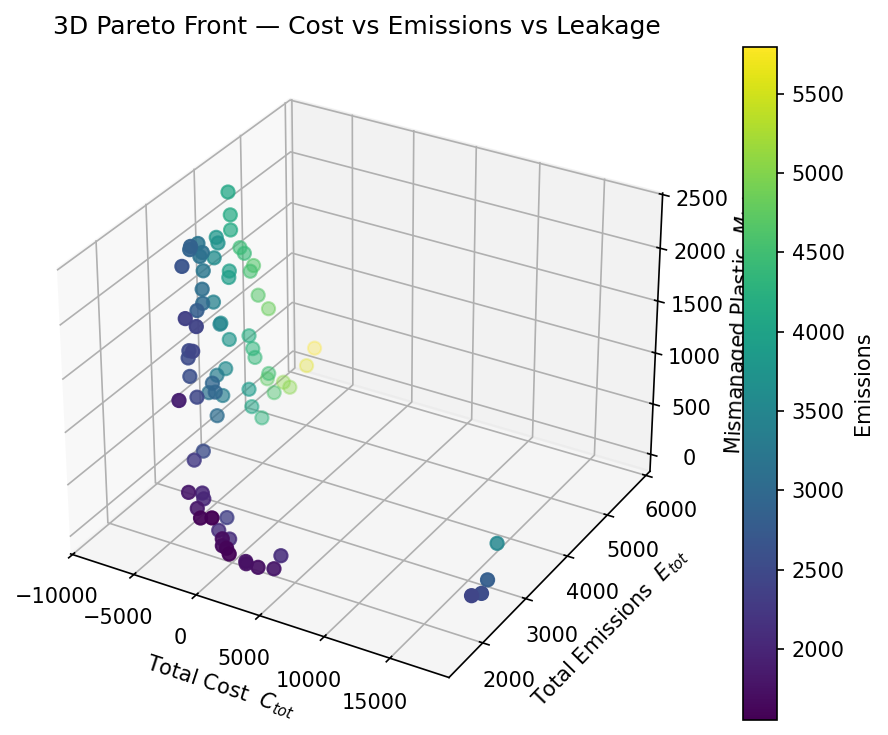

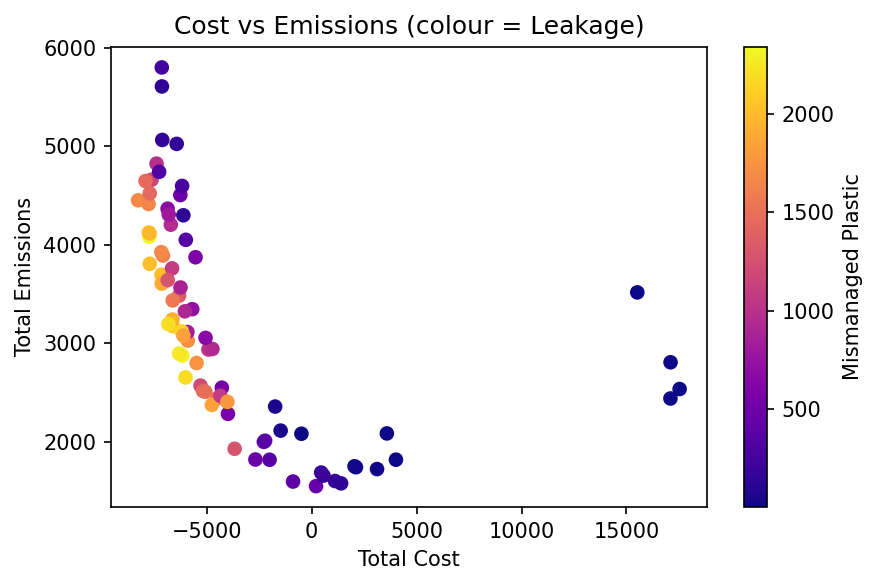

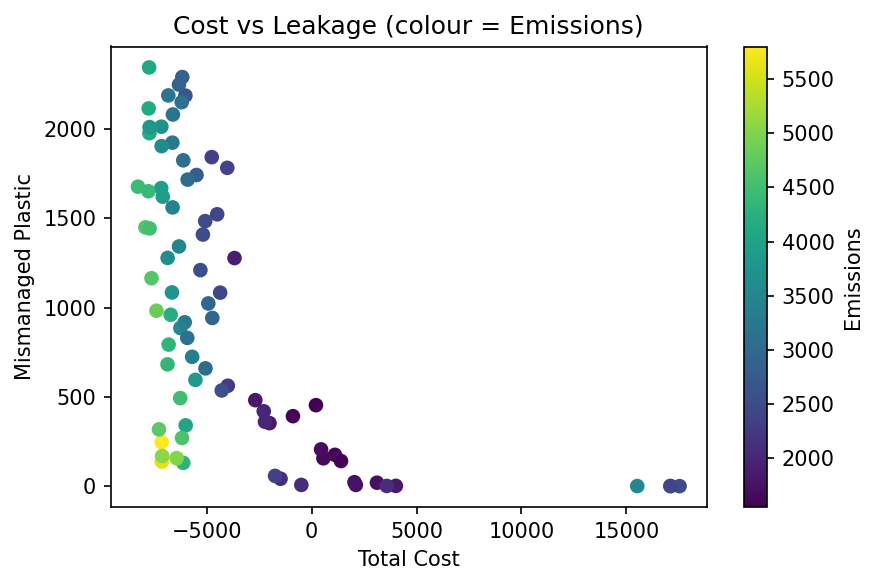

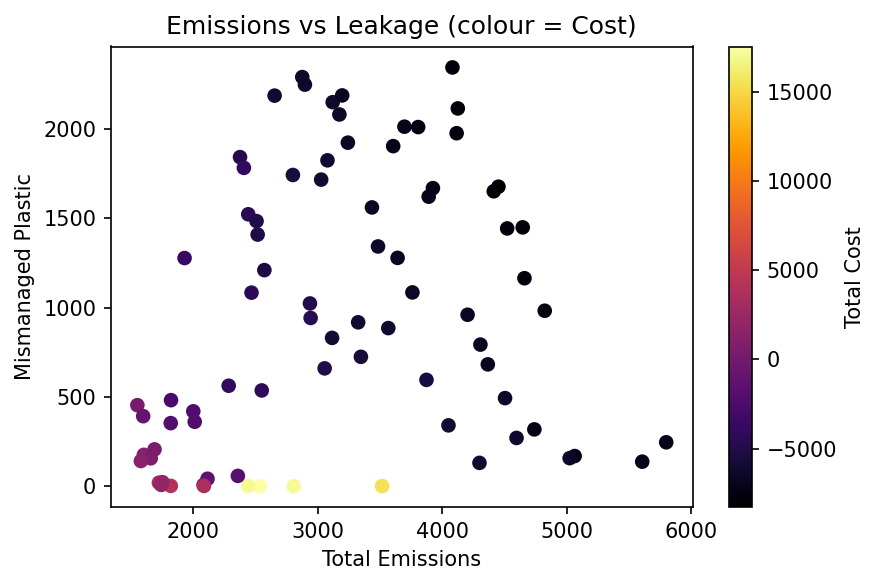

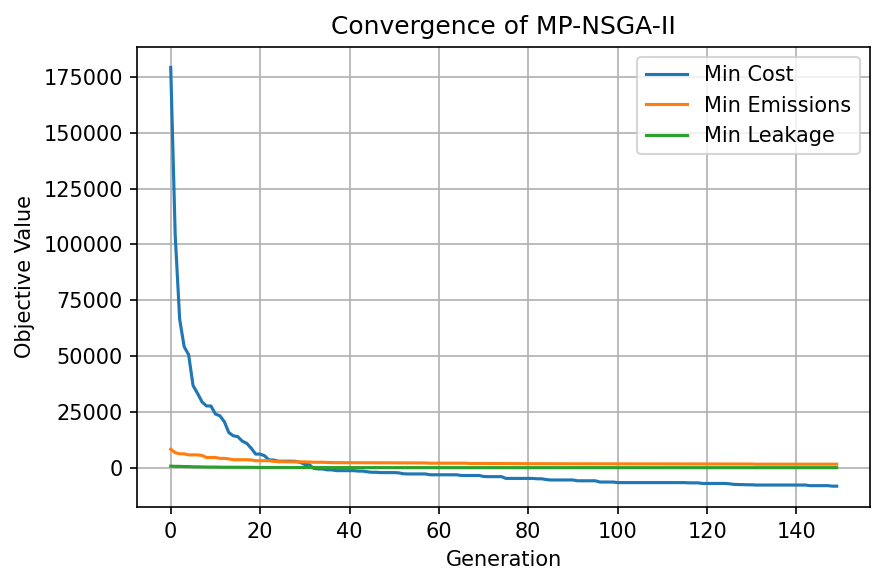

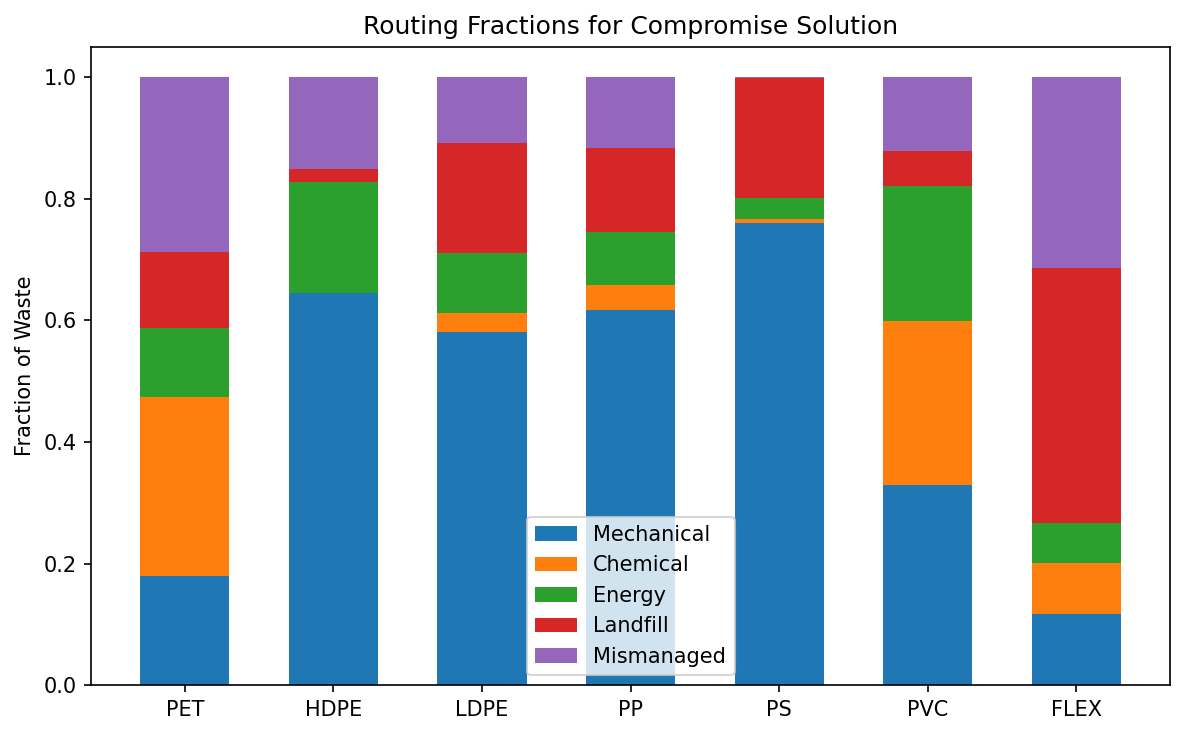


PART 5 completed — All baseline figures generated.



In [ ]:
# ===============================================================
# PART 5 — BASELINE PARETO EXTRACTION + PLOTS
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300


# ---------------------------------------------------------------
# 1. Extract first Pareto front from final objectives
# ---------------------------------------------------------------
def extract_pareto_front(objs):
    """
    Extract FIRST Pareto front using dominance criteria.
    objs : N x 3 array (C, E, M)
    """
    N = objs.shape[0]
    dominated = np.zeros(N, dtype=bool)

    for i in range(N):
        for j in range(N):
            if i != j:
                # j dominates i if:
                # j <= i for all objectives AND j < i in at least one objective
                if (objs[j] <= objs[i]).all() and (objs[j] < objs[i]).any():
                    dominated[i] = True
                    break

    return np.where(~dominated)[0]


# ---------------------------------------------------------------
# 2. Run baseline MP-NSGA-II
# ---------------------------------------------------------------
print("\nRunning baseline MP-NSGA-II...\n")

final_pop, final_objs, history = run_mp_nsga2(
    n_gen=N_GEN,
    pop_size=POP_SIZE,
    verbose=True
)

pareto_idx = extract_pareto_front(final_objs)
pareto = final_objs[pareto_idx]

print(f"\nPareto front size = {len(pareto_idx)}")
print("Objectives (C, E, M) — sample:")
print(pareto[:10])


# ---------------------------------------------------------------
# 3. FIGURE 1 — 3D Pareto Surface
# ---------------------------------------------------------------
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    pareto[:, 0], pareto[:, 1], pareto[:, 2],
    c=pareto[:, 1], cmap='viridis', s=40
)

ax.set_xlabel("Total Cost  $C_{tot}$")
ax.set_ylabel("Total Emissions  $E_{tot}$")
ax.set_zlabel("Mismanaged Plastic  $M_{tot}$")

plt.title("3D Pareto Front — Cost vs Emissions vs Leakage")
plt.colorbar(sc, label="Emissions")

plt.tight_layout()
plt.savefig("Fig1_3D_Pareto.png")
plt.show()


# ---------------------------------------------------------------
# 4. FIGURE 2 — 2D Trade-off Projections
# ---------------------------------------------------------------

# (a) Cost–Emissions
plt.figure(figsize=(6, 4))
plt.scatter(pareto[:, 0], pareto[:, 1], c=pareto[:, 2], cmap='plasma')
plt.xlabel("Total Cost")
plt.ylabel("Total Emissions")
plt.title("Cost vs Emissions (colour = Leakage)")
plt.colorbar(label="Mismanaged Plastic")
plt.tight_layout()
plt.savefig("Fig2a_Cost_Emissions.png")
plt.show()

# (b) Cost–Leakage
plt.figure(figsize=(6, 4))
plt.scatter(pareto[:, 0], pareto[:, 2], c=pareto[:, 1], cmap='viridis')
plt.xlabel("Total Cost")
plt.ylabel("Mismanaged Plastic")
plt.title("Cost vs Leakage (colour = Emissions)")
plt.colorbar(label="Emissions")
plt.tight_layout()
plt.savefig("Fig2b_Cost_Leakage.png")
plt.show()

# (c) Emissions–Leakage
plt.figure(figsize=(6, 4))
plt.scatter(pareto[:, 1], pareto[:, 2], c=pareto[:, 0], cmap='inferno')
plt.xlabel("Total Emissions")
plt.ylabel("Mismanaged Plastic")
plt.title("Emissions vs Leakage (colour = Cost)")
plt.colorbar(label="Total Cost")
plt.tight_layout()
plt.savefig("Fig2c_Emissions_Leakage.png")
plt.show()


# ---------------------------------------------------------------
# 5. FIGURE 3 — MP-NSGA-II Convergence Plot
# ---------------------------------------------------------------
gens = np.arange(len(history["min_cost"]))

plt.figure(figsize=(6, 4))
plt.plot(gens, history["min_cost"], label="Min Cost")
plt.plot(gens, history["min_emis"], label="Min Emissions")
plt.plot(gens, history["min_leak"], label="Min Leakage")
plt.xlabel("Generation")
plt.ylabel("Objective Value")
plt.title("Convergence of MP-NSGA-II")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Fig3_Convergence.png")
plt.show()


# ---------------------------------------------------------------
# 6. FIGURE 4 — Routing Profile (Corrected Keys)
# ---------------------------------------------------------------
def plot_routing(solution, title="Routing Fractions for Compromise Solution"):
    polymers = POLYMERS

    mech, chem, energy, land, mis = [], [], [], [], []

    for i in polymers:
        mech.append(solution[i]["x_mech"])
        chem.append(solution[i]["x_chem"])
        energy.append(solution[i]["x_energy"])
        land.append(solution[i]["x_landfill"])
        mis.append(solution[i]["x_mis"])

    ind = np.arange(len(polymers))
    width = 0.6

    plt.figure(figsize=(8, 5))
    plt.bar(ind, mech, width, label="Mechanical")
    plt.bar(ind, chem, width, bottom=np.array(mech), label="Chemical")
    plt.bar(ind, energy, width,
            bottom=np.array(mech)+np.array(chem), label="Energy")
    plt.bar(ind, land, width,
            bottom=np.array(mech)+np.array(chem)+np.array(energy), label="Landfill")
    plt.bar(ind, mis, width,
            bottom=np.array(mech)+np.array(chem)+np.array(energy)+np.array(land),
            label="Mismanaged")

    plt.xticks(ind, polymers)
    plt.ylabel("Fraction of Waste")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig("Fig4_RoutingProfile.png")
    plt.show()


# Select middle Pareto point as representative
mid_idx = pareto_idx[len(pareto_idx) // 2]
plot_routing(final_pop[mid_idx])

print("\nPART 5 completed — All baseline figures generated.\n")





========== Running Algorithm Comparison ==========


--- Run 1/3 ---

--- Run 2/3 ---

--- Run 3/3 ---

Completed all runs.



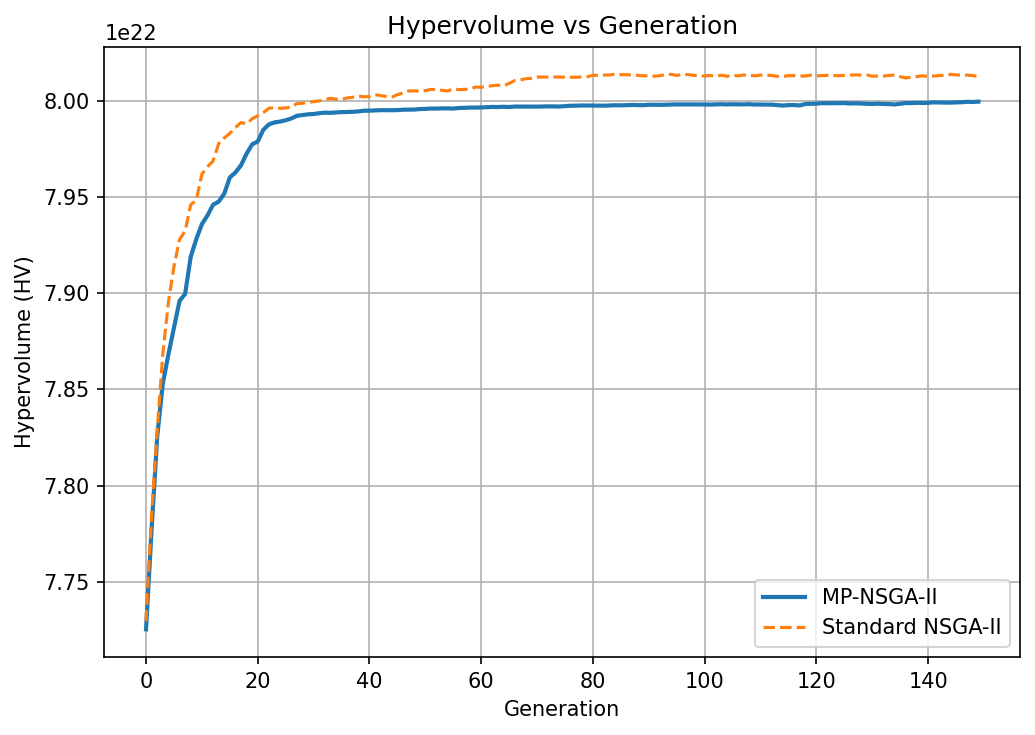

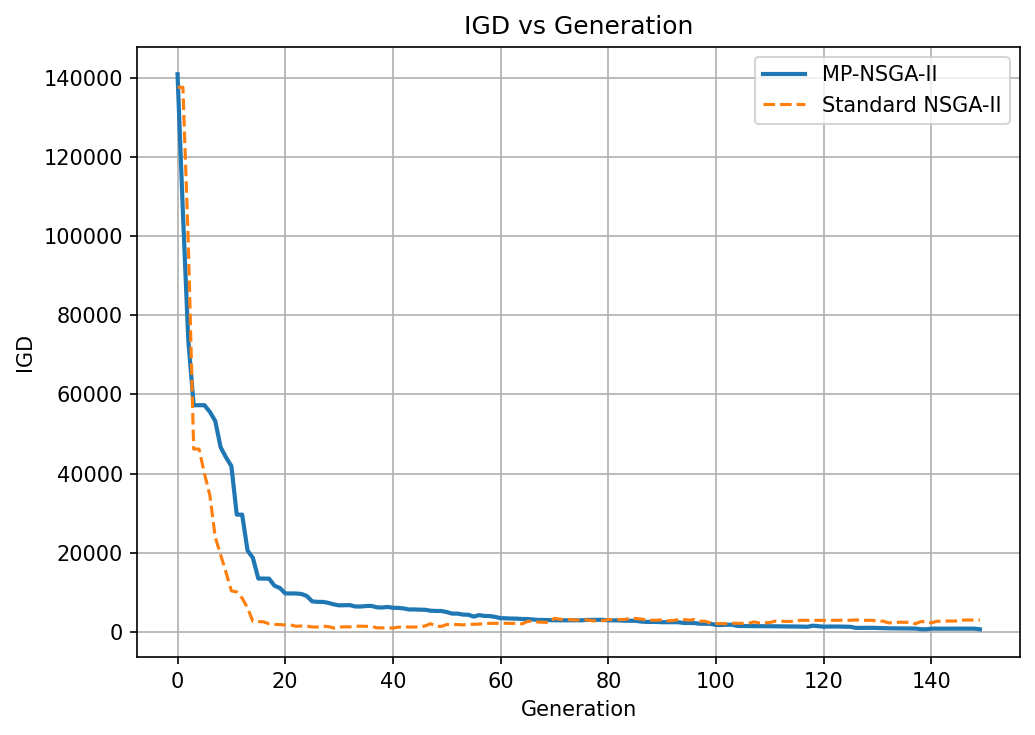


========== Algorithm Comparison Summary ==========

          Algorithm                             HV_mean  \
0        MP-NSGA-II 79,987,611,225,038,759,395,328.0000   
1  Standard NSGA-II 80,117,583,079,090,618,892,288.0000   

                           HV_std   IGD_mean  IGD_std  Runtime_mean_sec  
0  5,352,657,221,617,099,776.0000   974.7166 227.7433           61.2755  
1 14,918,765,769,727,303,680.0000 2,496.3500 315.5309           63.9160  

Saved: Table_Algorithm_Comparison.csv


In [ ]:
# ===============================================================
# PART 6 — Algorithm Comparison: MP-NSGA-II vs Standard NSGA-II
# ===============================================================

import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

# ---------------------------------------------------------------
# 0. Flat-vector encoding for STANDARD NSGA-II
# ---------------------------------------------------------------

# Order of decision variables PER POLYMER in flat vector
VAR_ORDER = [
    "price", "G", "r",
    "x_mech", "x_chem", "x_energy", "x_landfill", "x_mis",
    "P_V", "T_F", "tau"
]
N_PER_POLY = len(VAR_ORDER)
N_POLY = len(POLYMERS)
N_VAR = N_PER_POLY * N_POLY

# Precompute bounds in the same order as VAR_ORDER
VAR_LOW = []
VAR_HIGH = []
for _i in POLYMERS:
    for key in VAR_ORDER:
        lo, hi = bounds[key]
        VAR_LOW.append(lo)
        VAR_HIGH.append(hi)
VAR_LOW = np.array(VAR_LOW, dtype=float)
VAR_HIGH = np.array(VAR_HIGH, dtype=float)


def flat_to_solution(flat):
    """
    Map a flat numpy vector (length N_VAR) to the structured solution
    dictionary used by evaluate_solution().
    """
    sol = {}
    idx = 0

    for i in POLYMERS:
        price      = flat[idx]; idx += 1
        G          = flat[idx]; idx += 1
        r          = flat[idx]; idx += 1
        x_mech     = flat[idx]; idx += 1
        x_chem     = flat[idx]; idx += 1
        x_energy   = flat[idx]; idx += 1
        x_landfill = flat[idx]; idx += 1
        x_mis      = flat[idx]; idx += 1
        P_V        = flat[idx]; idx += 1
        T_F        = flat[idx]; idx += 1
        tau        = flat[idx]; idx += 1

        sol[i] = {
            "price": price,
            "G": G,
            "r": r,
            "x_mech": x_mech,
            "x_chem": x_chem,
            "x_energy": x_energy,
            "x_landfill": x_landfill,
            "x_mis": x_mis,
            "P_V": P_V,
            "T_F": T_F,
            "tau": tau,
        }

        # Normalise routing fractions so they sum to 1
        total = x_mech + x_chem + x_energy + x_landfill + x_mis
        if total <= 0:
            # default if degenerate
            sol[i]["x_mech"] = 1.0
            sol[i]["x_chem"] = 0.0
            sol[i]["x_energy"] = 0.0
            sol[i]["x_landfill"] = 0.0
            sol[i]["x_mis"] = 0.0
        else:
            sol[i]["x_mech"]     /= total
            sol[i]["x_chem"]     /= total
            sol[i]["x_energy"]   /= total
            sol[i]["x_landfill"] /= total
            sol[i]["x_mis"]      /= total

    return sol


def initialize_population_std(pop_size):
    """
    Initialise standard NSGA-II population as flat vectors in [VAR_LOW, VAR_HIGH].
    """
    pop = []
    for _ in range(pop_size):
        x = VAR_LOW + (VAR_HIGH - VAR_LOW) * np.random.rand(N_VAR)
        pop.append(x)
    return np.array(pop)


def evaluate_population_std(pop_flat):
    """
    Evaluate a population of flat vectors via evaluate_solution(flat_to_solution).
    Returns (N,3) objective array.
    """
    N = pop_flat.shape[0]
    objs = np.zeros((N, 3), dtype=float)
    for i in range(N):
        sol = flat_to_solution(pop_flat[i])
        objs[i, :] = evaluate_solution(sol)
    return objs


# ---------------------------------------------------------------
# 1. Standard NSGA-II operators on flat vectors
# ---------------------------------------------------------------

def tournament_select_std(objs, ranks, crowding, k=2):
    """
    Binary tournament selection on indices using (rank, crowding).
    """
    N = objs.shape[0]
    candidates = np.random.choice(N, size=k, replace=False)
    best = candidates[0]
    for c in candidates[1:]:
        if ranks[c] < ranks[best]:
            best = c
        elif ranks[c] == ranks[best]:
            if crowding[c] > crowding[best]:
                best = c
    return best


def sbx_crossover_std(p1, p2, eta_c=ETA_C, p_c=P_CROSS):
    """
    SBX crossover for flat numpy vectors.
    Returns two children.
    """
    if np.random.rand() > p_c:
        return p1.copy(), p2.copy()

    child1 = p1.copy()
    child2 = p2.copy()

    for j in range(N_VAR):
        x1 = p1[j]
        x2 = p2[j]
        xl = VAR_LOW[j]
        xu = VAR_HIGH[j]

        if np.random.rand() <= 0.5:
            if abs(x1 - x2) > 1e-14:
                if x1 > x2:
                    x1, x2 = x2, x1

                rand = np.random.rand()
                beta = 1.0 + (2.0 * (x1 - xl) / (x2 - x1))
                alpha_ = 2.0 - beta ** -(eta_c + 1.0)

                if rand <= 1.0 / alpha_:
                    betaq = (rand * alpha_) ** (1.0 / (eta_c + 1.0))
                else:
                    betaq = (1.0 / (2.0 - rand * alpha_)) ** (1.0 / (eta_c + 1.0))

                c1 = 0.5 * ((x1 + x2) - betaq * (x2 - x1))
                c2 = 0.5 * ((x1 + x2) + betaq * (x2 - x1))

                c1 = np.clip(c1, xl, xu)
                c2 = np.clip(c2, xl, xu)

                child1[j] = c1
                child2[j] = c2
            else:
                child1[j] = x1
                child2[j] = x2

    return child1, child2


def gaussian_mutation_std(x, p_mut=0.1, sigma_frac=0.1):
    """
    Simple Gaussian mutation with per-variable probability p_mut.
    """
    y = x.copy()
    for j in range(N_VAR):
        if np.random.rand() < p_mut:
            lo = VAR_LOW[j]
            hi = VAR_HIGH[j]
            sigma = sigma_frac * (hi - lo)
            y[j] += np.random.normal(0.0, sigma)
            y[j] = np.clip(y[j], lo, hi)
    return y


def nd_selection_std(pop, objs, pop_size):
    """
    Standard NSGA-II environmental selection on flat vectors.
    Uses fast_non_dominated_sort and crowding_distance from Part 4.
    """
    fronts = fast_non_dominated_sort(objs)
    new_pop = []
    new_objs = []

    for front in fronts:
        if len(new_pop) + len(front) > pop_size:
            distances = crowding_distance(objs, front)
            sorted_front = sorted(front, key=lambda idx: distances[idx], reverse=True)
            remaining = pop_size - len(new_pop)
            chosen = sorted_front[:remaining]
        else:
            chosen = front

        for idx in chosen:
            new_pop.append(pop[idx])
            new_objs.append(objs[idx])

        if len(new_pop) == pop_size:
            break

    return np.array(new_pop), np.vstack(new_objs)


# ---------------------------------------------------------------
# 2. Hypervolume & IGD utilities
# ---------------------------------------------------------------
# Use MP-NSGA-II Pareto front from Part 5 as IGD reference
pareto_reference_front = pareto.copy()


def compute_hypervolume(objs, ref_point):
    """
    Very simple HV: sum of positive (ref - point) box volumes.
    """
    diff = ref_point - objs
    vol = np.prod(diff, axis=1)
    vol = vol[vol > 0]
    return vol.sum()


def compute_igd(objs, reference):
    """
    IGD = average distance from each reference point to nearest solution.
    """
    total = 0.0
    for r in reference:
        d = np.linalg.norm(objs - r, axis=1)
        total += d.min()
    return total / len(reference)


# ---------------------------------------------------------------
# 3. Run STANDARD NSGA-II with HV & IGD history
# ---------------------------------------------------------------
def run_standard_nsga2(n_gen, pop_size, verbose=False):
    """
    Standard NSGA-II:
      - Flattened decision vectors
      - SBX crossover
      - Gaussian mutation
      - No polymer-specific repair, no adaptive mutation.
    Returns pop, objs, history dict with hv & igd.
    """
    pop = initialize_population_std(pop_size)
    objs = evaluate_population_std(pop)

    history = {"hv": [], "igd": []}
    ref_point = np.array([1e7, 1e7, 1e7], dtype=float)

    for g in range(n_gen):
        # Record metrics
        hv = compute_hypervolume(objs, ref_point)
        igd = compute_igd(objs, pareto_reference_front)
        history["hv"].append(hv)
        history["igd"].append(igd)

        # Non-dominated sorting & crowding for selection
        fronts = fast_non_dominated_sort(objs)
        ranks = np.zeros(pop.shape[0], dtype=int)
        crowd = np.zeros(pop.shape[0], dtype=float)
        for f_idx, front in enumerate(fronts):
            for idx in front:
                ranks[idx] = f_idx
            dist = crowding_distance(objs, front)
            for idx, d in dist.items():
                crowd[idx] = d

        # Mating pool (indices)
        mating_idx = []
        while len(mating_idx) < pop_size:
            sel = tournament_select_std(objs, ranks, crowd, k=2)
            mating_idx.append(sel)

        # Variation
        children = []
        for j in range(0, pop_size, 2):
            p1 = pop[mating_idx[j]]
            p2 = pop[mating_idx[(j + 1) % pop_size]]
            c1, c2 = sbx_crossover_std(p1, p2)
            c1 = gaussian_mutation_std(c1, p_mut=0.1)
            c2 = gaussian_mutation_std(c2, p_mut=0.1)
            children.append(c1)
            children.append(c2)

        children = np.array(children[:pop_size])
        child_objs = evaluate_population_std(children)

        # Environmental selection on combined
        combined_pop = np.vstack([pop, children])
        combined_objs = np.vstack([objs, child_objs])
        pop, objs = nd_selection_std(combined_pop, combined_objs, pop_size)

        if verbose and (g % 10 == 0 or g == n_gen - 1):
            print(f"[Std NSGA-II] Gen {g:4d} | HV={hv:.2e}, IGD={igd:.2f}")

    return pop, objs, history


# ---------------------------------------------------------------
# 4. Run MP-NSGA-II with HV & IGD history (wrapper around existing)
# ---------------------------------------------------------------
def run_mp_nsga2_with_metrics(n_gen, pop_size, verbose=False):
    """
    Wrapper around your existing run_mp_nsga2 to also track HV & IGD.
    Uses the same internal operators as Part 4.
    """
    pop = [initialize_solution() for _ in range(pop_size)]
    objs = evaluate_population(pop)

    history = {"hv": [], "igd": []}
    ref_point = np.array([1e7, 1e7, 1e7], dtype=float)

    for g in range(n_gen):
        hv = compute_hypervolume(objs, ref_point)
        igd = compute_igd(objs, pareto_reference_front)
        history["hv"].append(hv)
        history["igd"].append(igd)

        if verbose and (g % 10 == 0 or g == n_gen - 1):
            print(
                f"[MP-NSGA-II] Gen {g:4d} | "
                f"HV={hv:.2e}, IGD={igd:.2f}, "
                f"minC={objs[:,0].min():.2f}, minE={objs[:,1].min():.2f}, minM={objs[:,2].min():.2f}"
            )

        # Use your Part 4 logic to get next generation
        pop, objs = make_next_generation(pop, objs)

    return pop, objs, history


# ---------------------------------------------------------------
# 5. Run both algorithms multiple times + summary metrics
# ---------------------------------------------------------------
N_RUNS = 3  # you can increase to 5 or 10 later

metrics = {
    "mp_hv": [], "mp_igd": [], "mp_time": [],
    "ns_hv": [], "ns_igd": [], "ns_time": [],
}

print("\n========== Running Algorithm Comparison ==========\n")

# We will also keep the last run histories for plotting HV/IGD vs Gen
mp_hist_last = None
ns_hist_last = None

for run in range(N_RUNS):
    print(f"\n--- Run {run + 1}/{N_RUNS} ---")

    # MP-NSGA-II
    t0 = time.time()
    mp_pop, mp_objs, mp_hist = run_mp_nsga2_with_metrics(N_GEN, POP_SIZE, verbose=False)
    t1 = time.time()
    mp_time = t1 - t0
    mp_hv_final = compute_hypervolume(mp_objs, np.array([1e7, 1e7, 1e7]))
    mp_igd_final = compute_igd(mp_objs, pareto_reference_front)

    metrics["mp_hv"].append(mp_hv_final)
    metrics["mp_igd"].append(mp_igd_final)
    metrics["mp_time"].append(mp_time)

    mp_hist_last = mp_hist  # for plotting

    # Standard NSGA-II
    t0 = time.time()
    ns_pop, ns_objs, ns_hist = run_standard_nsga2(N_GEN, POP_SIZE, verbose=False)
    t1 = time.time()
    ns_time = t1 - t0
    ns_hv_final = compute_hypervolume(ns_objs, np.array([1e7, 1e7, 1e7]))
    ns_igd_final = compute_igd(ns_objs, pareto_reference_front)

    metrics["ns_hv"].append(ns_hv_final)
    metrics["ns_igd"].append(ns_igd_final)
    metrics["ns_time"].append(ns_time)

    ns_hist_last = ns_hist  # for plotting

print("\nCompleted all runs.\n")


# ---------------------------------------------------------------
# 6. Plot HV and IGD vs Generation (using last run)
# ---------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(mp_hist_last["hv"], label="MP-NSGA-II", linewidth=2)
plt.plot(ns_hist_last["hv"], label="Standard NSGA-II", linestyle="--")
plt.xlabel("Generation")
plt.ylabel("Hypervolume (HV)")
plt.title("Hypervolume vs Generation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Fig6a_HV_vs_Gen.png")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(mp_hist_last["igd"], label="MP-NSGA-II", linewidth=2)
plt.plot(ns_hist_last["igd"], label="Standard NSGA-II", linestyle="--")
plt.xlabel("Generation")
plt.ylabel("IGD")
plt.title("IGD vs Generation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Fig6b_IGD_vs_Gen.png")
plt.show()


# ---------------------------------------------------------------
# 7. Summary Table (Mean ± std over runs)
# ---------------------------------------------------------------
summary_df = pd.DataFrame({
    "Algorithm": ["MP-NSGA-II", "Standard NSGA-II"],
    "HV_mean":   [np.mean(metrics["mp_hv"]), np.mean(metrics["ns_hv"])],
    "HV_std":    [np.std(metrics["mp_hv"]),  np.std(metrics["ns_hv"])],
    "IGD_mean":  [np.mean(metrics["mp_igd"]), np.mean(metrics["ns_igd"])],
    "IGD_std":   [np.std(metrics["mp_igd"]),  np.std(metrics["ns_igd"])],
    "Runtime_mean_sec": [np.mean(metrics["mp_time"]), np.mean(metrics["ns_time"])]
})

print("\n========== Algorithm Comparison Summary ==========\n")
print(summary_df)

summary_df.to_csv("Table_Algorithm_Comparison.csv", index=False)
print("\nSaved: Table_Algorithm_Comparison.csv")





===== Running Carbon Price Scenarios =====
Scenario: Low, Carbon Price = 0.0
Scenario: Baseline, Carbon Price = 0.0
Scenario: High, Carbon Price = 10.0

===== Running Green Budget Scenarios =====
Scenario: Tight, GREEN_BUDGET = 75000.0
Scenario: Baseline, GREEN_BUDGET = 150000.0
Scenario: High, GREEN_BUDGET = 225000.0

===== Running Leakage Cap Scenarios =====
Scenario: Strict, PB_LIMIT (leakage cap) = 2500.0
Scenario: Baseline, PB_LIMIT (leakage cap) = 5000.0
Scenario: Relaxed, PB_LIMIT (leakage cap) = 10000.0


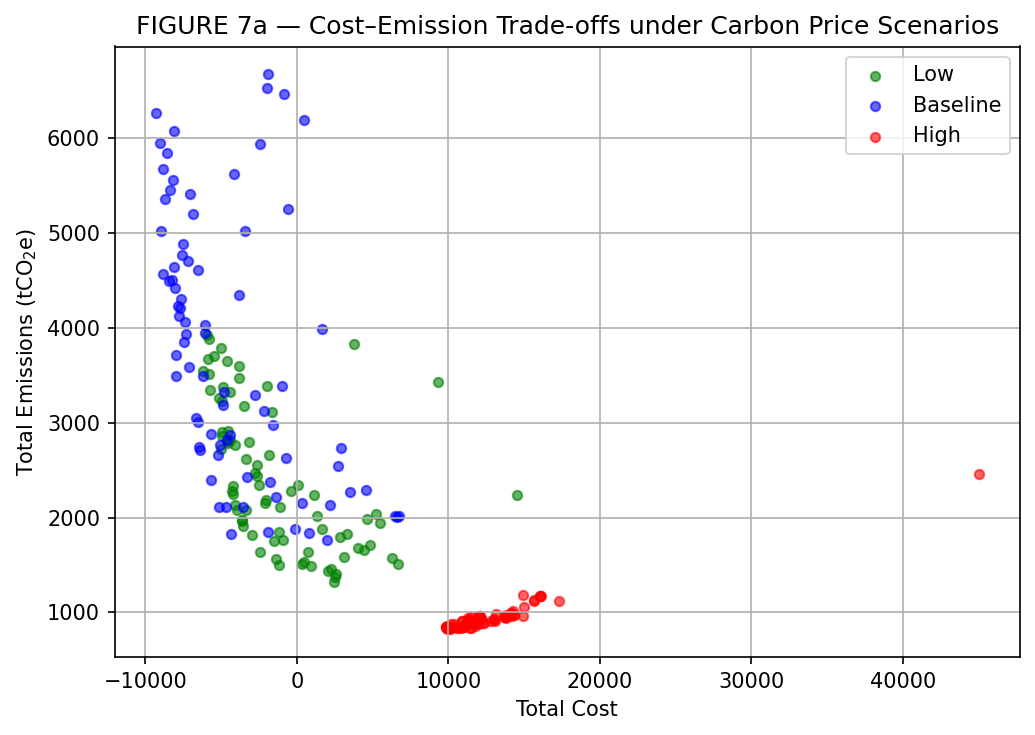

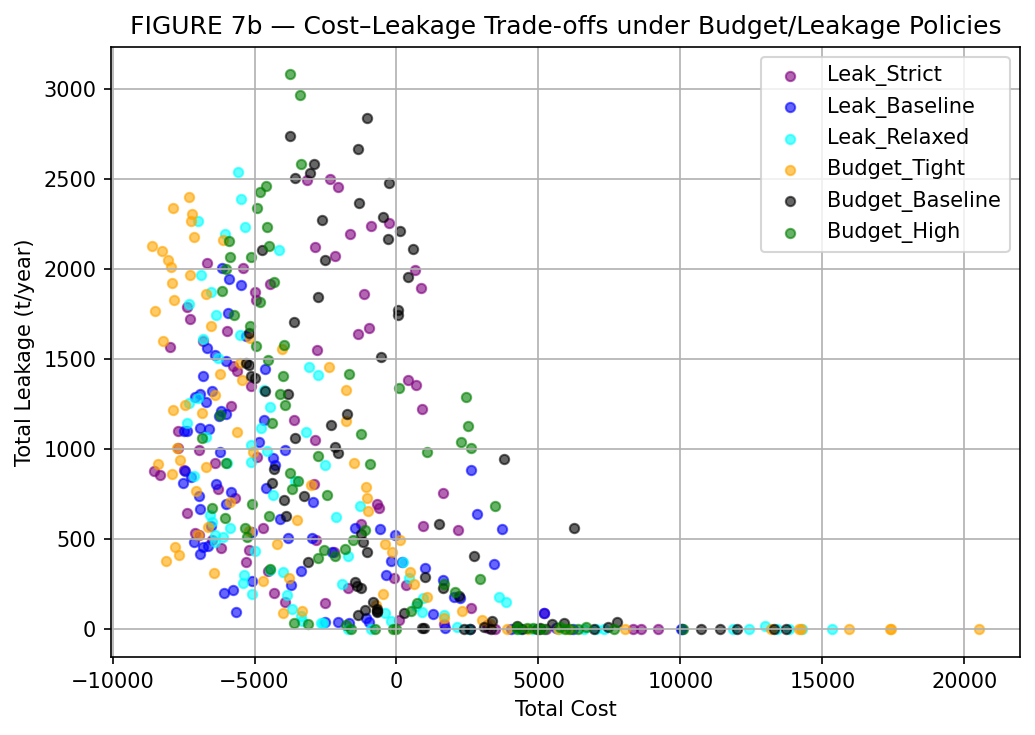


Saved scenario results → ScenarioResults.pkl

Saved: Table_Policy_Scenario_Summary.csv


,Scenario Type,Scenario,Mean Cost,Mean Emissions,Mean Leakage
0,carbon_price,Low,"-1,197.5497","2,418.1724",439.8176
1,carbon_price,Baseline,"-4,199.6162","3,787.0919",670.0675
2,carbon_price,High,"12,545.0022",942.2458,3.4756
3,green_budget,Tight,"-2,244.3467","2,701.0569",884.0559
4,green_budget,Baseline,420.6311,"2,792.6794",904.0928
5,green_budget,High,"-1,409.1213","3,595.1682",917.7260
6,leakage_cap,Strict,"-2,401.2586","3,079.2887",989.7586
7,leakage_cap,Baseline,"-3,157.2611","3,032.3939",705.8357
8,leakage_cap,Relaxed,"-1,485.5321","4,556.8667",683.9095


In [ ]:
# ===============================================================
# PART 7 — Policy Scenario Analysis (Carbon Price, Budget, Leakage Caps)
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 350


# ---------------------------------------------------------------
# 1. Define Scenarios
# ---------------------------------------------------------------

# Baseline values taken from existing globals:
#   - P_carbon     : used in total_cost() for carbon pricing
#   - GREEN_BUDGET : used in green_budget_repair()
#   - PB_LIMIT     : used in leakage_cap_repair() and is_feasible()
BASE_CARBON_PRICE = P_carbon
BASE_GBUDGET = GREEN_BUDGET
BASE_LEAKAGE_CAP = PB_LIMIT

# Scenario levels
carbon_price_levels = {
    "Low":      0.5 * BASE_CARBON_PRICE,
    "Baseline": BASE_CARBON_PRICE,
    "High":     2.0 * BASE_CARBON_PRICE if BASE_CARBON_PRICE > 0 else 10.0
    # if baseline is 0, make "High" a positive carbon price
}

green_budget_levels = {
    "Tight":    0.5 * BASE_GBUDGET,
    "Baseline": BASE_GBUDGET,
    "High":     1.5 * BASE_GBUDGET
}

leakage_cap_levels = {
    "Strict":   0.5 * BASE_LEAKAGE_CAP,
    "Baseline": BASE_LEAKAGE_CAP,
    "Relaxed":  2.0 * BASE_LEAKAGE_CAP
}


# ---------------------------------------------------------------
# 2. Utility function to run one scenario
# ---------------------------------------------------------------
def run_scenario(carbon_price=None, green_budget=None, leakage_cap=None):
    """
    Runs MP-NSGA-II under modified policy values:
      - carbon_price  → P_carbon
      - green_budget  → GREEN_BUDGET
      - leakage_cap   → PB_LIMIT
    Returns: (final_pop, final_objs)
    """
    global P_carbon, GREEN_BUDGET, PB_LIMIT

    # store old values
    old_pc = P_carbon
    old_gb = GREEN_BUDGET
    old_pb = PB_LIMIT

    # apply scenario changes
    if carbon_price is not None:
        P_carbon = carbon_price
    if green_budget is not None:
        GREEN_BUDGET = green_budget
    if leakage_cap is not None:
        PB_LIMIT = leakage_cap

    # run algorithm (uses current globals via total_cost, leakage_aware_repair, etc.)
    pop, objs, _ = run_mp_nsga2(
        n_gen=N_GEN,
        pop_size=POP_SIZE,
        verbose=False
    )

    # restore baseline
    P_carbon = old_pc
    GREEN_BUDGET = old_gb
    PB_LIMIT = old_pb

    return pop, objs


# ---------------------------------------------------------------
# 3. Run Carbon Price Scenarios
# ---------------------------------------------------------------

scenario_results_carbon = {}

print("\n===== Running Carbon Price Scenarios =====")
for name, value in carbon_price_levels.items():
    print(f"Scenario: {name}, Carbon Price = {value}")
    _, objs = run_scenario(carbon_price=value)
    scenario_results_carbon[name] = objs


# ---------------------------------------------------------------
# 4. Run Green Budget Scenarios
# ---------------------------------------------------------------

scenario_results_budget = {}

print("\n===== Running Green Budget Scenarios =====")
for name, value in green_budget_levels.items():
    print(f"Scenario: {name}, GREEN_BUDGET = {value}")
    _, objs = run_scenario(green_budget=value)
    scenario_results_budget[name] = objs


# ---------------------------------------------------------------
# 5. Run Leakage Cap Scenarios
# ---------------------------------------------------------------

scenario_results_leak = {}

print("\n===== Running Leakage Cap Scenarios =====")
for name, value in leakage_cap_levels.items():
    print(f"Scenario: {name}, PB_LIMIT (leakage cap) = {value}")
    _, objs = run_scenario(leakage_cap=value)
    scenario_results_leak[name] = objs


# ---------------------------------------------------------------
# 6. Plot Figure 7a – Cost vs Emissions under Carbon Price Scenarios
# ---------------------------------------------------------------

plt.figure(figsize=(7, 5))

colors = {"Low": "green", "Baseline": "blue", "High": "red"}

for name, objs in scenario_results_carbon.items():
    plt.scatter(objs[:, 0], objs[:, 1], s=20, alpha=0.6,
                label=name, color=colors.get(name, None))

plt.xlabel("Total Cost")
plt.ylabel("Total Emissions (tCO$_2$e)")
plt.title("FIGURE 7a — Cost–Emission Trade-offs under Carbon Price Scenarios")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Fig7a_Cost_Emission_CarbonPrice.png")
plt.show()


# ---------------------------------------------------------------
# 7. Plot Figure 7b – Cost vs Leakage for Leakage Cap + Budget Scenarios
# ---------------------------------------------------------------

plt.figure(figsize=(7, 5))

# combine leakage scenarios and budget scenarios
combined_scenarios = {
    f"Leak_{name}": objs for name, objs in scenario_results_leak.items()
}
combined_scenarios.update({
    f"Budget_{name}": objs for name, objs in scenario_results_budget.items()
})

colors2 = {
    "Leak_Strict": "purple",
    "Leak_Baseline": "blue",
    "Leak_Relaxed": "cyan",
    "Budget_Tight": "orange",
    "Budget_Baseline": "black",
    "Budget_High": "green"
}

for name, objs in combined_scenarios.items():
    plt.scatter(objs[:, 0], objs[:, 2], s=20, alpha=0.6,
                label=name, color=colors2.get(name, None))

plt.xlabel("Total Cost")
plt.ylabel("Total Leakage (t/year)")
plt.title("FIGURE 7b — Cost–Leakage Trade-offs under Budget/Leakage Policies")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Fig7b_Cost_Leakage_Policies.png")
plt.show()


# ---------------------------------------------------------------
# 8. Save all scenario data
# ---------------------------------------------------------------
scenario_data = {
    "carbon_price": scenario_results_carbon,
    "green_budget": scenario_results_budget,
    "leakage_cap": scenario_results_leak
}

with open("ScenarioResults.pkl", "wb") as f:
    pickle.dump(scenario_data, f)

print("\nSaved scenario results → ScenarioResults.pkl")


# ---------------------------------------------------------------
# 9. Create Overleaf-friendly CSV summary
# ---------------------------------------------------------------
summary_rows = []

for category, dic in scenario_data.items():
    for name, objs in dic.items():
        row = {
            "Scenario Type": category,
            "Scenario": name,
            "Mean Cost": float(objs[:, 0].mean()),
            "Mean Emissions": float(objs[:, 1].mean()),
            "Mean Leakage": float(objs[:, 2].mean())
        }
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("Table_Policy_Scenario_Summary.csv", index=False)

print("\nSaved: Table_Policy_Scenario_Summary.csv")
summary_df




===== Baseline run for sensitivity reference =====
Gen    0 | min C = 167106.49, min E = 9111.77, min M = 907.53
Gen   10 | min C = 9340.91, min E = 3488.23, min M = 251.15
Gen   20 | min C = 727.11, min E = 3031.11, min M = 108.25
Gen   30 | min C = -538.01, min E = 2459.67, min M = 25.10
Gen   40 | min C = -2319.01, min E = 2191.19, min M = 5.69
Gen   50 | min C = -3338.82, min E = 1851.65, min M = 4.38
Gen   60 | min C = -3838.55, min E = 1845.72, min M = 1.88
Gen   70 | min C = -4229.14, min E = 1845.72, min M = 0.95
Gen   80 | min C = -4561.37, min E = 1738.28, min M = 0.36
Gen   90 | min C = -4855.65, min E = 1638.71, min M = 0.23
Gen  100 | min C = -5215.44, min E = 1574.76, min M = 0.13
Gen  110 | min C = -5561.20, min E = 1574.76, min M = 0.09
Gen  120 | min C = -6194.34, min E = 1574.76, min M = 0.07
Gen  130 | min C = -6741.52, min E = 1488.12, min M = 0.05
Gen  140 | min C = -6741.52, min E = 1488.12, min M = 0.03
Gen  149 | min C = -7581.32, min E = 1481.03, min M = 0.02


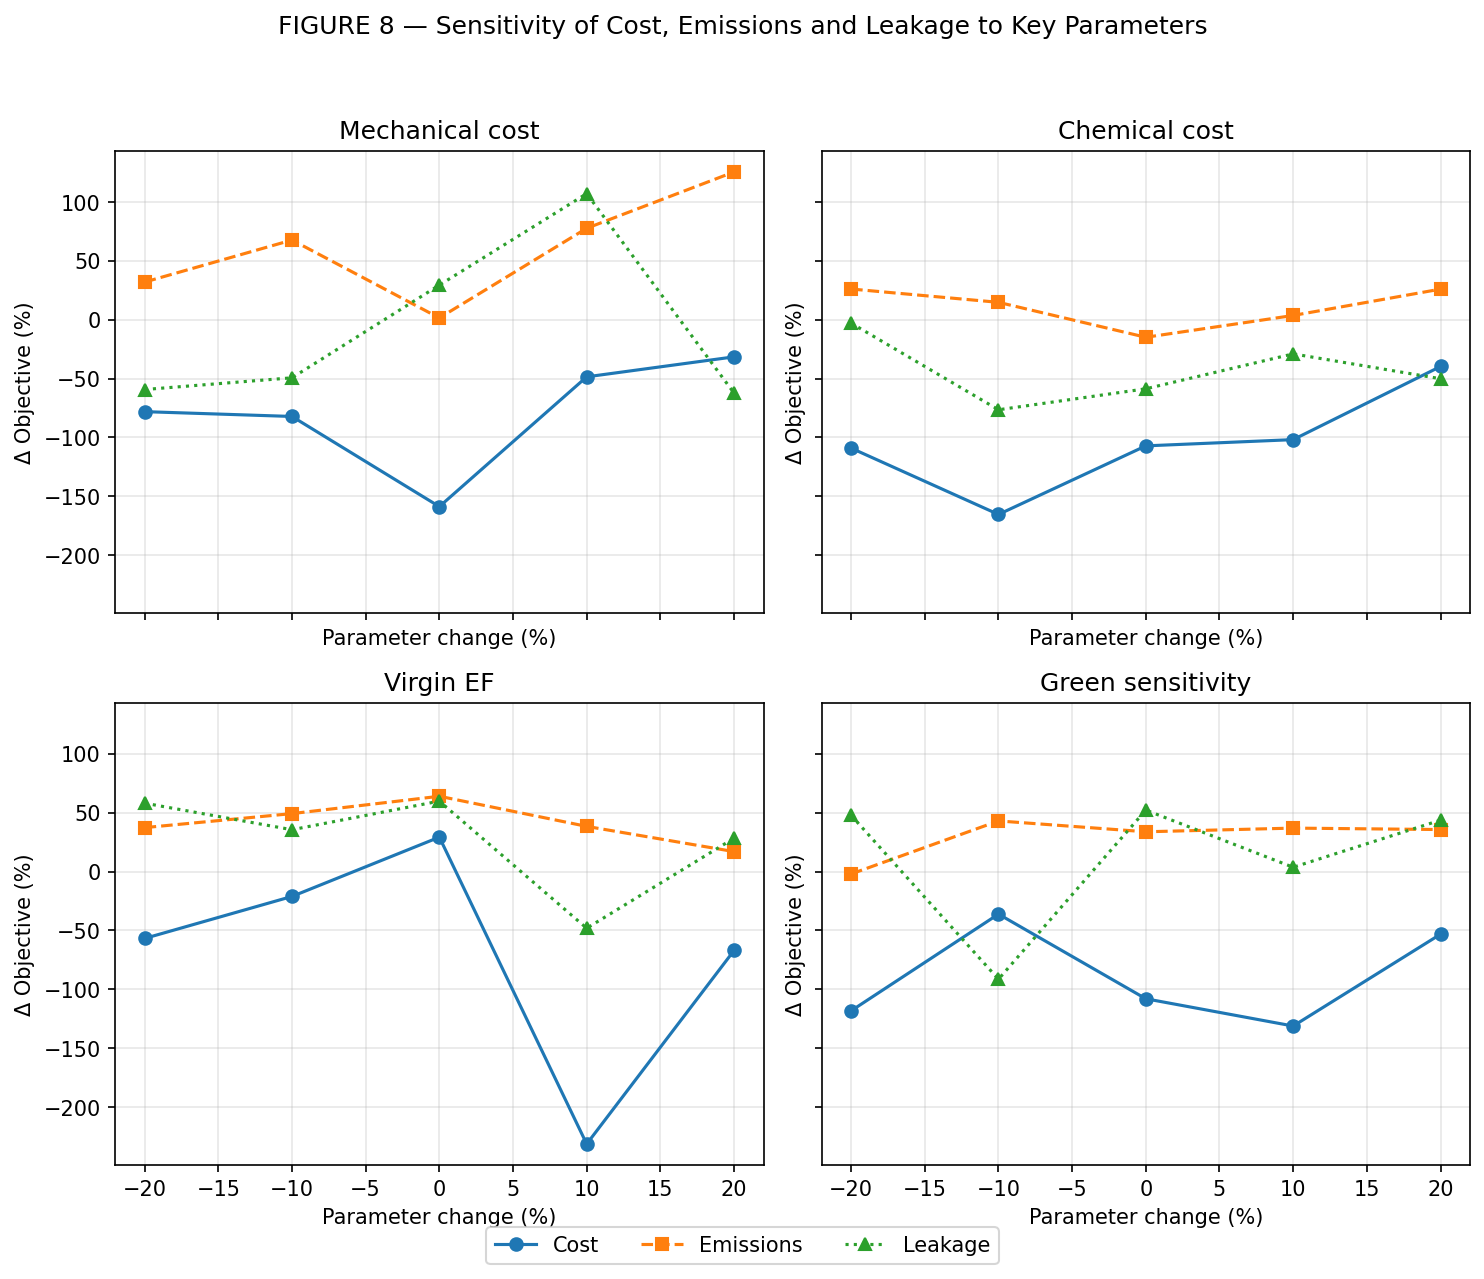

Saved sensitivity table: Sensitivity_Mechanical_cost.csv
Saved sensitivity table: Sensitivity_Chemical_cost.csv
Saved sensitivity table: Sensitivity_Virgin_EF.csv
Saved sensitivity table: Sensitivity_Green_sensitivity.csv

Saved combined sensitivity workbook: Sensitivity_All_Params.xlsx


,Change_%,Cost,Emissions,Leakage,dCost_%,dEmissions_%,dLeakage_%
0,-20.0000,-600.0955,"2,981.1194",120.3301,-78.1089,31.9831,-59.3086
1,-10.0000,-488.0364,"3,787.7164",149.7944,-82.1967,67.6936,-49.3448
2,0.0000,"1,611.2813","2,292.5649",382.6448,-158.7785,1.4987,29.3970
3,10.0000,"-1,410.9786","4,013.5859",612.4632,-48.5284,77.6935,107.1135
4,20.0000,"-1,876.2655","5,094.4423",111.3042,-31.5550,125.5463,-62.3608


In [ ]:
# ===============================================================
# PART 8 — Sensitivity and Robustness Analysis (±20%)
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 350


# ---------------------------------------------------------------
# 1. Helper: choose a "compromise" solution from a Pareto set
# ---------------------------------------------------------------
def choose_compromise_solution(objs: np.ndarray):
    """
    Given an (N, 3) array of [Cost, Emission, Leakage],
    return the index of a compromise solution:
    - Normalise each objective to [0, 1]
    - Compute distance to origin (0,0,0)
    - Pick the minimum distance point
    """
    mins = objs.min(axis=0)
    maxs = objs.max(axis=0)
    denom = (maxs - mins)
    denom[denom == 0.0] = 1.0  # avoid divide-by-zero

    norm = (objs - mins) / denom
    dist = np.linalg.norm(norm, axis=1)
    idx = np.argmin(dist)
    return idx


# ---------------------------------------------------------------
# 2. Baseline compromise solution (for reference)
# ---------------------------------------------------------------
print("\n===== Baseline run for sensitivity reference =====")
baseline_sol, baseline_objs, _ = run_mp_nsga2(N_GEN, POP_SIZE)

idx_base = choose_compromise_solution(baseline_objs)
baseline_C, baseline_E, baseline_M = baseline_objs[idx_base]

print(f"Baseline compromise solution index = {idx_base}")
print(f"Baseline: Cost={baseline_C:.3f}, Emissions={baseline_E:.3f}, Leakage={baseline_M:.3f}")


# ---------------------------------------------------------------
# 3. General sensitivity runner for one parameter family
# ---------------------------------------------------------------
SENS_LEVELS = np.array([-0.2, -0.1, 0.0, 0.1, 0.2])  # ±20% and ±10%

def run_sensitivity_for_array(label, get_array_fn, set_array_fn,
                              gens_factor=0.6, pop_factor=0.75):
    """
    Generic sensitivity routine for parameters that are stored as
    a numpy array (ordered by POLYMERS).

    label         : string label (e.g., 'Mechanical cost')
    get_array_fn  : function returning the current numpy array (shape = (#polymers,))
    set_array_fn  : function taking a numpy array and assigning it back to globals
    gens_factor   : to reduce N_GEN for sensitivity runs
    pop_factor    : to reduce POP_SIZE for sensitivity runs
    """
    print(f"\n===== Sensitivity for {label} =====")

    # use fewer generations / smaller population to reduce runtime
    N_GEN_SENS = max(50, int(N_GEN * gens_factor))
    POP_SENS   = max(40, int(POP_SIZE * pop_factor))

    base_arr = get_array_fn().copy()

    records = []

    for change in SENS_LEVELS:
        factor = 1.0 + change
        print(f"\n  -> Running change {change*100:+.0f}% (factor={factor:.2f})")

        # apply perturbation
        perturbed = base_arr * factor
        set_array_fn(perturbed)

        # run MP-NSGA-II with perturbed parameter
        sol, objs, _ = run_mp_nsga2(N_GEN_SENS, POP_SENS, verbose=False)

        # pick compromise from this perturbed Pareto set
        idx = choose_compromise_solution(objs)
        C, E, M = objs[idx]

        # store results
        records.append({
            "Change_%": change * 100.0,
            "Cost": C,
            "Emissions": E,
            "Leakage": M
        })

        # restore baseline array for next loop
        set_array_fn(base_arr)

    # convert to DataFrame
    df = pd.DataFrame(records)

    # compute percentage changes relative to baseline compromise solution
    df["dCost_%"]      = 100.0 * (df["Cost"]      - baseline_C) / baseline_C
    df["dEmissions_%"] = 100.0 * (df["Emissions"] - baseline_E) / baseline_E
    df["dLeakage_%"]   = 100.0 * (df["Leakage"]   - baseline_M) / baseline_M

    return df


# ---------------------------------------------------------------
# 4. Wrap get/set functions for each parameter (DICT → ARRAY)
# ---------------------------------------------------------------
# NOTE: we always respect the order of POLYMERS = ["PET","HDPE","LDPE","PP","PS","PVC","FLEX"]

# 4(a) Mechanical recycling cost C_R_mech[i]
def get_c_mech():
    """Return mechanical cost as array in polymer order."""
    return np.array([C_R_mech[i] for i in POLYMERS], dtype=float)

def set_c_mech(arr):
    """Write mechanical cost array back into C_R_mech dict."""
    global C_R_mech
    for i, pol in enumerate(POLYMERS):
        C_R_mech[pol] = float(arr[i])


# 4(b) Chemical recycling cost C_R_chem[i]
def get_c_chem():
    return np.array([C_R_chem[i] for i in POLYMERS], dtype=float)

def set_c_chem(arr):
    global C_R_chem
    for i, pol in enumerate(POLYMERS):
        C_R_chem[pol] = float(arr[i])


# 4(c) Virgin emission factor EF_V[i]
def get_EF_virgin():
    return np.array([EF_V[i] for i in POLYMERS], dtype=float)

def set_EF_virgin(arr):
    global EF_V
    for i, pol in enumerate(POLYMERS):
        EF_V[pol] = float(arr[i])


# 4(d) Demand green-sensitivity delta[(i,"pack")]
#      (you are using SEGMENTS = ["pack"], so we perturb that entry for each polymer)
def get_delta_green():
    return np.array([delta[(i, "pack")] for i in POLYMERS], dtype=float)

def set_delta_green(arr):
    global delta
    for idx, pol in enumerate(POLYMERS):
        delta[(pol, "pack")] = float(arr[idx])


# ---------------------------------------------------------------
# 5. Run sensitivity for each parameter group
# ---------------------------------------------------------------
sens_results = {}

sens_results["Mechanical cost"] = run_sensitivity_for_array(
    "Mechanical cost", get_c_mech, set_c_mech
)

sens_results["Chemical cost"] = run_sensitivity_for_array(
    "Chemical cost", get_c_chem, set_c_chem
)

sens_results["Virgin EF"] = run_sensitivity_for_array(
    "Virgin emission factor", get_EF_virgin, set_EF_virgin
)

sens_results["Green sensitivity"] = run_sensitivity_for_array(
    "Demand green-sensitivity", get_delta_green, set_delta_green
)


# ---------------------------------------------------------------
# 6. Plot Figure 8 – Sensitivity curves (Cost, Emissions, Leakage)
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (label, df) in zip(axes, sens_results.items()):
    ax.plot(df["Change_%"], df["dCost_%"],      marker="o", linestyle="-",  label="Cost")
    ax.plot(df["Change_%"], df["dEmissions_%"], marker="s", linestyle="--", label="Emissions")
    ax.plot(df["Change_%"], df["dLeakage_%"],   marker="^", linestyle=":",  label="Leakage")

    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Parameter change (%)")
    ax.set_ylabel("Δ Objective (%)")

# Shared legend
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("FIGURE 8 — Sensitivity of Cost, Emissions and Leakage to Key Parameters",
             y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig("Fig8_Sensitivity_Parameters.png", bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------
# 7. Save sensitivity tables (CSV) for Overleaf
# ---------------------------------------------------------------
for label, df in sens_results.items():
    fname = f"Sensitivity_{label.replace(' ', '_')}.csv"
    df.to_csv(fname, index=False)
    print(f"Saved sensitivity table: {fname}")

# Optional: combined Excel workbook
with pd.ExcelWriter("Sensitivity_All_Params.xlsx") as writer:
    for label, df in sens_results.items():
        sheet_name = label.replace(" ", "_")[0:31]  # Excel sheet name limit
        df.to_excel(writer, sheet_name=sheet_name, index=False)

print("\nSaved combined sensitivity workbook: Sensitivity_All_Params.xlsx")

# Show one example table
sens_results["Mechanical cost"]



Number of Pareto solutions used for Figure 9: 80


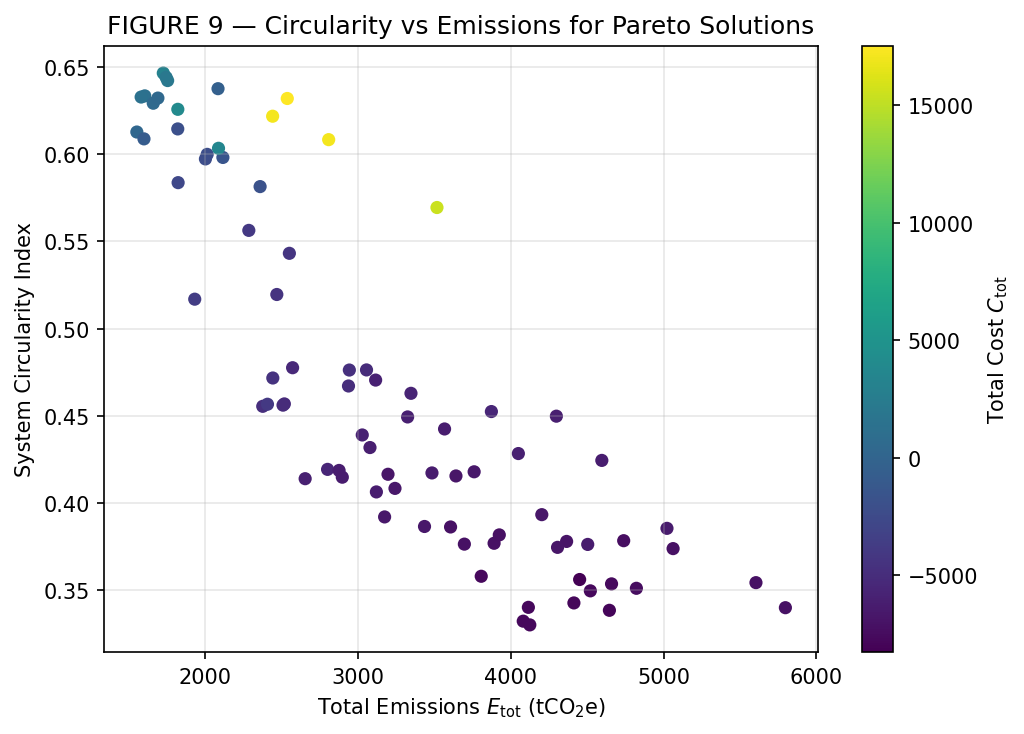


Saved: Fig9_Circularity_vs_Emissions.png


In [ ]:
# ======================================================================
# FIGURE 9 — System-level Circularity vs Emissions Trade-off
# ======================================================================

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 400


# ----------------------------------------------------------------------
# 0. Safety check — ensure MP-NSGA-II and utilities exist
# ----------------------------------------------------------------------
missing = []

if "run_mp_nsga2" not in globals():
    missing.append("run_mp_nsga2")

if "circularity_index" not in globals():
    missing.append("circularity_index")

if "extract_pareto_front" not in globals():
    # define Pareto extractor here
    def extract_pareto_front(objs: np.ndarray):
        N = objs.shape[0]
        dominated = np.zeros(N, dtype=bool)
        for i in range(N):
            for j in range(N):
                if i == j:
                    continue
                if np.all(objs[j] <= objs[i]) and np.any(objs[j] < objs[i]):
                    dominated[i] = True
                    break
        return np.where(~dominated)[0]

if missing:
    print("\n[WARNING] The following functions were not found:", missing)
    print("You must run the earlier model-definition cells first.")
    raise NameError("Missing required functions for Figure 9.")

# ----------------------------------------------------------------------
# 1. Ensure Pareto population exists
# ----------------------------------------------------------------------
if "final_pop" not in globals() or "final_objs" not in globals():
    print("\nfinal_pop/final_objs not found – running MP-NSGA-II again...\n")
    final_pop, final_objs, history = run_mp_nsga2(
        n_gen=N_GEN,
        pop_size=POP_SIZE,
        verbose=True
    )

# ----------------------------------------------------------------------
# 2. Extract Pareto front and compute circularity index
# ----------------------------------------------------------------------
pareto_idx   = extract_pareto_front(final_objs)
pareto_objs  = final_objs[pareto_idx]

E_pareto = pareto_objs[:, 1]   # Emissions
C_pareto = pareto_objs[:, 0]   # Cost

circ_pareto = np.array([
    circularity_index(final_pop[idx]) for idx in pareto_idx
])

print(f"Number of Pareto solutions used for Figure 9: {len(pareto_idx)}")

# ----------------------------------------------------------------------
# 3. Generate high-resolution plot
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    E_pareto,
    circ_pareto,
    c=C_pareto,
    cmap="viridis",
    s=40,
    edgecolors="none"
)

ax.set_xlabel(r"Total Emissions $E_{\text{tot}}$ (tCO$_2$e)")
ax.set_ylabel(r"System Circularity Index")
ax.set_title(r"FIGURE 9 — Circularity vs Emissions for Pareto Solutions")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"Total Cost $C_{\text{tot}}$")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Fig9_Circularity_vs_Emissions.png", dpi=400, bbox_inches="tight")
plt.show()

print("\nSaved: Fig9_Circularity_vs_Emissions.png")


In [ ]:
import numpy as np

# First, extract key stats
E_min, E_max = final_objs[:,1].min(), final_objs[:,1].max()
C_min, C_max = final_objs[:,0].min(), final_objs[:,0].max()
M_min, M_max = final_objs[:,2].min(), final_objs[:,2].max()

# compromise solution
idx = np.argmin(np.linalg.norm((final_objs-final_objs.min(axis=0)) / (final_objs.max(axis=0)-final_objs.min(axis=0)), axis=1))
C_base, E_base, M_base = final_objs[idx]

print("=== Pareto Range ===")
print("Cost: min =",C_min,", max =",C_max)
print("Emissions: min =",E_min,", max =",E_max)
print("Leakage: min =",M_min,", max =",M_max)

print("\n=== Compromise Solution ===")
print("Cost =",C_base)
print("Emissions =",E_base)
print("Leakage =",M_base)

# circularity stats
circ_vals = np.array([circularity_index(sol) for sol in final_pop])
print("\nCircularity: min =",circ_vals.min(),", max =",circ_vals.max())


=== Pareto Range ===
Cost: min = -8275.879261606759 , max = 17536.046330903424
Emissions: min = 1551.8761319339374 , max = 5798.036791055051
Leakage: min = 0.8205476584531404 , max = 2342.8770419909442

=== Compromise Solution ===
Cost = -2008.6856827582917
Emissions = 1819.7529238151242
Leakage = 353.3767118730298

Circularity: min = 0.3301187564429379 , max = 0.646439632511444



Running baseline MP-NSGA-II...

Gen    0 | min C = 121237.66, min E = 7215.68, min M = 914.14
Gen   10 | min C = 11519.01, min E = 4847.78, min M = 102.31
Gen   20 | min C = 2545.15, min E = 3536.79, min M = 30.32
Gen   30 | min C = 338.58, min E = 3243.77, min M = 6.72
Gen   40 | min C = -473.30, min E = 2582.78, min M = 4.87
Gen   50 | min C = -1370.73, min E = 2233.79, min M = 2.39
Gen   60 | min C = -2380.40, min E = 2002.78, min M = 1.86
Gen   70 | min C = -3766.78, min E = 1813.00, min M = 1.86
Gen   80 | min C = -4287.76, min E = 1721.43, min M = 1.27
Gen   90 | min C = -4413.38, min E = 1622.00, min M = 1.13
Gen  100 | min C = -4774.15, min E = 1593.14, min M = 0.79
Gen  110 | min C = -5268.62, min E = 1592.38, min M = 0.79
Gen  120 | min C = -5717.73, min E = 1523.10, min M = 0.43
Gen  130 | min C = -6122.45, min E = 1420.88, min M = 0.41
Gen  140 | min C = -6122.45, min E = 1412.33, min M = 0.41
Gen  149 | min C = -6428.11, min E = 1412.33, min M = 0.41
MP-NSGA-II completed.

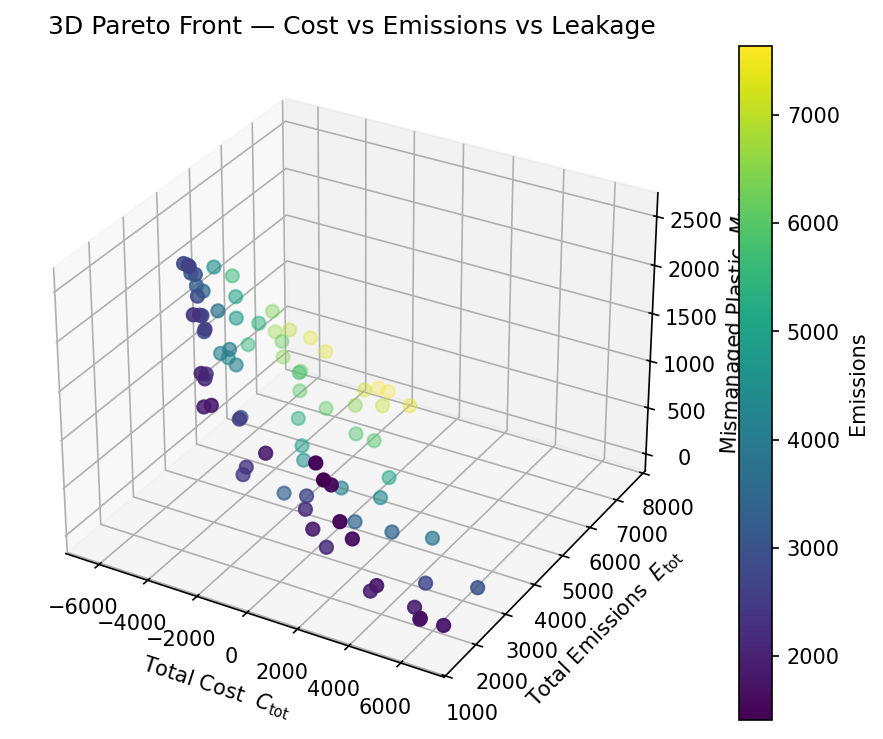

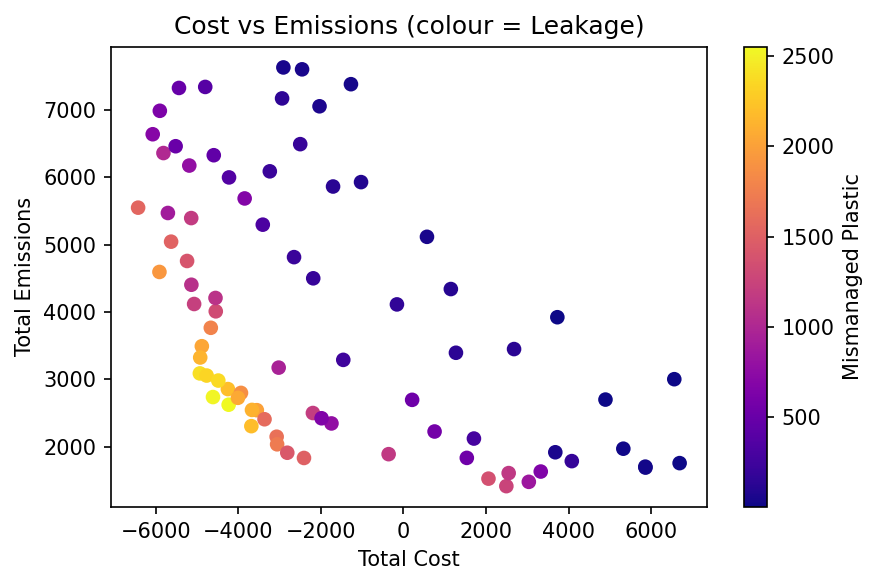

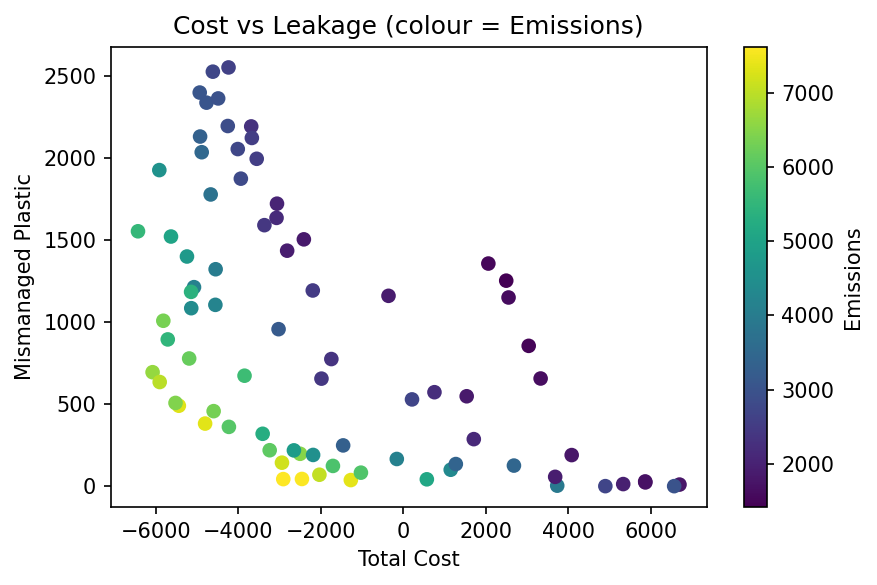

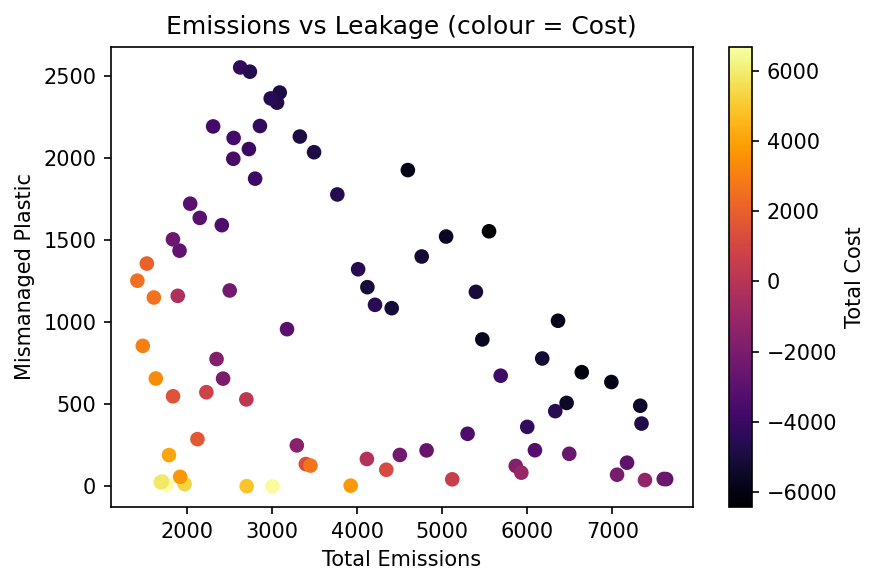

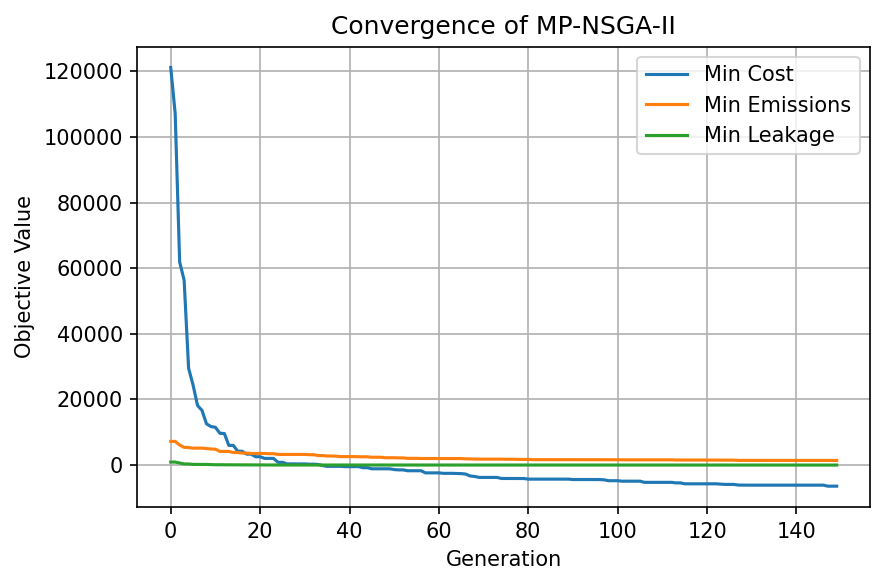

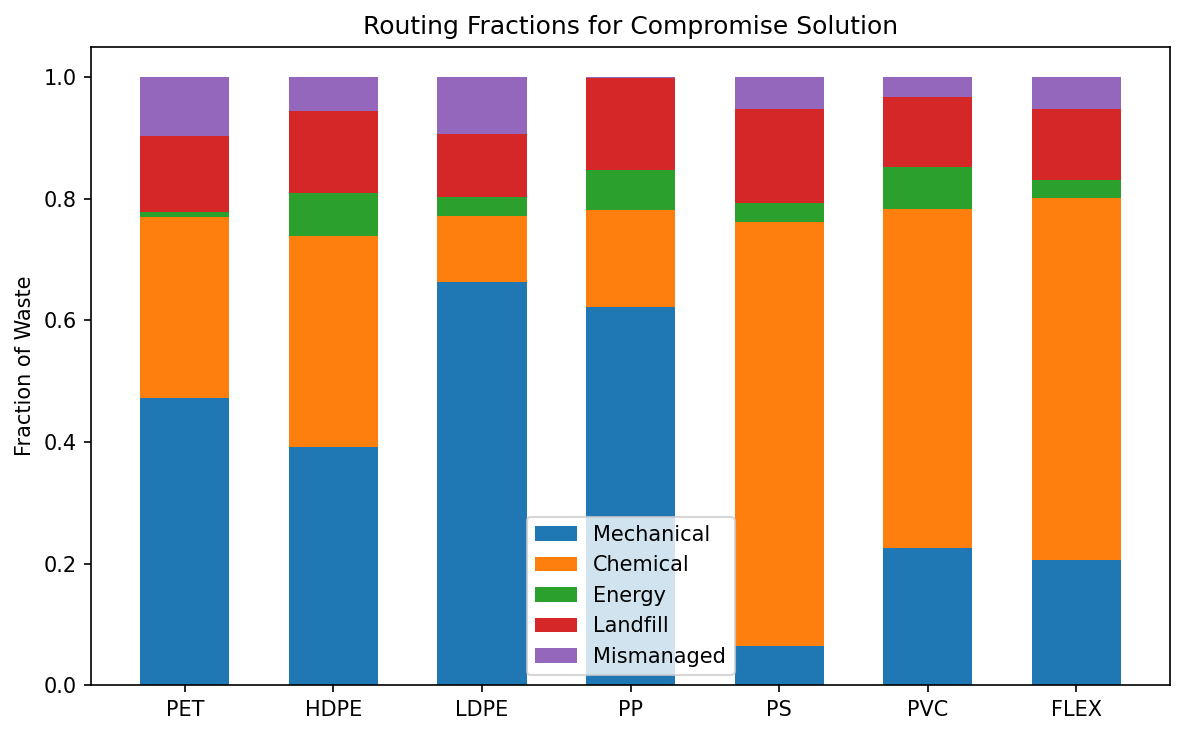


PART 5 completed — All baseline figures generated and optimal compromise solution printed.



In [ ]:
# ===============================================================
# PART 5 — BASELINE PARETO EXTRACTION + PLOTS + OPTIMAL SOLUTION
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300


# ---------------------------------------------------------------
# 1. Extract first Pareto front from final objectives
# ---------------------------------------------------------------
def extract_pareto_front(objs):
    """
    Extract FIRST Pareto front using dominance criteria.
    objs : N x 3 array (C, E, M)
    """
    N = objs.shape[0]
    dominated = np.zeros(N, dtype=bool)

    for i in range(N):
        for j in range(N):
            if i != j:
                # j dominates i if:
                # j <= i for all objectives AND j < i in at least one objective
                if (objs[j] <= objs[i]).all() and (objs[j] < objs[i]).any():
                    dominated[i] = True
                    break

    return np.where(~dominated)[0]


# ---------------------------------------------------------------
# 2. Run baseline MP-NSGA-II
# ---------------------------------------------------------------
print("\nRunning baseline MP-NSGA-II...\n")

final_pop, final_objs, history = run_mp_nsga2(
    n_gen=N_GEN,
    pop_size=POP_SIZE,
    verbose=True
)

# final_objs is assumed to be an array of shape (N, 3): [C, E, M]
pareto_idx = extract_pareto_front(final_objs)
pareto = final_objs[pareto_idx]

print(f"\nPareto front size = {len(pareto_idx)}")
print("Objectives (C, E, M) — first 10 Pareto points:")
print(pareto[:10])


# ---------------------------------------------------------------
# 2a. Objective ranges and compromise (knee) solution
# ---------------------------------------------------------------
# Compute objective ranges across the Pareto set
C_min, C_max = pareto[:, 0].min(), pareto[:, 0].max()
E_min, E_max = pareto[:, 1].min(), pareto[:, 1].max()
M_min, M_max = pareto[:, 2].min(), pareto[:, 2].max()

print("\nObjective ranges across the non-dominated set:")
print(f"  C_min = {C_min:.2f},  C_max = {C_max:.2f}")
print(f"  E_min = {E_min:.2f},  E_max = {E_max:.2f}")
print(f"  M_min = {M_min:.2f},  M_max = {M_max:.2f}")

# Find a representative compromise (knee) solution:
# distance to utopia point in normalised objective space
utopia = np.array([C_min, E_min, M_min])
ranges = np.array([
    max(C_max - C_min, 1e-9),
    max(E_max - E_min, 1e-9),
    max(M_max - M_min, 1e-9),
])

# Normalise and compute Euclidean distance
norm_pareto = (pareto - utopia) / ranges
dist = np.linalg.norm(norm_pareto, axis=1)

knee_local_idx = np.argmin(dist)        # index within pareto array
knee_global_idx = pareto_idx[knee_local_idx]  # index within final_pop / final_objs

knee_objs = final_objs[knee_global_idx]
knee_solution = final_pop[knee_global_idx]

print("\nSelected compromise (knee) solution on the Pareto front:")
print(f"  Index in population: {knee_global_idx}")
print(f"  Objectives: C_tot = {knee_objs[0]:.2f}, "
      f"E_tot = {knee_objs[1]:.2f}, "
      f"M_tot = {knee_objs[2]:.2f}")

# Try to print all decision variables in a structured way
print("\nDecision variables for the compromise solution:")

if isinstance(knee_solution, dict):
    # Assume structure: {polymer: {var: value, ...}, ...}
    for pol, var_dict in knee_solution.items():
        print(f"\n  Polymer: {pol}")
        if isinstance(var_dict, dict):
            for k, v in var_dict.items():
                print(f"    {k:20s} = {v}")
        else:
            print(f"    (Non-dict entry) = {var_dict}")
else:
    # Fallback: assume array-like decision vector
    print(np.array(knee_solution))


# ---------------------------------------------------------------
# 3. FIGURE 1 — 3D Pareto Surface
# ---------------------------------------------------------------
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    pareto[:, 0], pareto[:, 1], pareto[:, 2],
    c=pareto[:, 1],
    cmap='viridis',
    s=40
)

ax.set_xlabel(r"Total Cost  $C_{\text{tot}}$")
ax.set_ylabel(r"Total Emissions  $E_{\text{tot}}$")
ax.set_zlabel(r"Mismanaged Plastic  $M_{\text{tot}}$")

plt.title("3D Pareto Front — Cost vs Emissions vs Leakage")
plt.colorbar(sc, label="Emissions")
plt.tight_layout()
plt.savefig("Fig1_3D_Pareto.png")
plt.show()


# ---------------------------------------------------------------
# 4. FIGURE 2 — 2D Trade-off Projections
# ---------------------------------------------------------------

# (a) Cost–Emissions
plt.figure(figsize=(6, 4))
plt.scatter(pareto[:, 0], pareto[:, 1], c=pareto[:, 2], cmap='plasma')
plt.xlabel("Total Cost")
plt.ylabel("Total Emissions")
plt.title("Cost vs Emissions (colour = Leakage)")
plt.colorbar(label="Mismanaged Plastic")
plt.tight_layout()
plt.savefig("Fig2a_Cost_Emissions.png")
plt.show()

# (b) Cost–Leakage
plt.figure(figsize=(6, 4))
plt.scatter(pareto[:, 0], pareto[:, 2], c=pareto[:, 1], cmap='viridis')
plt.xlabel("Total Cost")
plt.ylabel("Mismanaged Plastic")
plt.title("Cost vs Leakage (colour = Emissions)")
plt.colorbar(label="Emissions")
plt.tight_layout()
plt.savefig("Fig2b_Cost_Leakage.png")
plt.show()

# (c) Emissions–Leakage
plt.figure(figsize=(6, 4))
plt.scatter(pareto[:, 1], pareto[:, 2], c=pareto[:, 0], cmap='inferno')
plt.xlabel("Total Emissions")
plt.ylabel("Mismanaged Plastic")
plt.title("Emissions vs Leakage (colour = Cost)")
plt.colorbar(label="Total Cost")
plt.tight_layout()
plt.savefig("Fig2c_Emissions_Leakage.png")
plt.show()


# ---------------------------------------------------------------
# 5. FIGURE 3 — MP-NSGA-II Convergence Plot
# ---------------------------------------------------------------
gens = np.arange(len(history["min_cost"]))

plt.figure(figsize=(6, 4))
plt.plot(gens, history["min_cost"], label="Min Cost")
plt.plot(gens, history["min_emis"], label="Min Emissions")
plt.plot(gens, history["min_leak"], label="Min Leakage")
plt.xlabel("Generation")
plt.ylabel("Objective Value")
plt.title("Convergence of MP-NSGA-II")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Fig3_Convergence.png")
plt.show()


# ---------------------------------------------------------------
# 6. FIGURE 4 — Routing Profile (using compromise solution)
# ---------------------------------------------------------------
def plot_routing(solution, title="Routing Fractions for Compromise Solution"):
    polymers = POLYMERS

    mech, chem, energy, land, mis = [], [], [], [], []

    for i in polymers:
        mech.append(solution[i]["x_mech"])
        chem.append(solution[i]["x_chem"])
        energy.append(solution[i]["x_energy"])
        land.append(solution[i]["x_landfill"])
        mis.append(solution[i]["x_mis"])

    ind = np.arange(len(polymers))
    width = 0.6

    plt.figure(figsize=(8, 5))
    plt.bar(ind, mech, width, label="Mechanical")
    plt.bar(ind, chem, width, bottom=np.array(mech), label="Chemical")
    plt.bar(ind, energy, width,
            bottom=np.array(mech) + np.array(chem), label="Energy")
    plt.bar(ind, land, width,
            bottom=np.array(mech) + np.array(chem) + np.array(energy),
            label="Landfill")
    plt.bar(ind, mis, width,
            bottom=np.array(mech) + np.array(chem)
            + np.array(energy) + np.array(land),
            label="Mismanaged")

    plt.xticks(ind, polymers)
    plt.ylabel("Fraction of Waste")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig("Fig4_RoutingProfile.png")
    plt.show()


# Use the compromise (knee) solution for routing profile
plot_routing(knee_solution)

print("\nPART 5 completed — All baseline figures generated and optimal compromise solution printed.\n")



========== Running Algorithm Comparison (5 methods) ==========


--- Run 1/3 ---

--- Run 2/3 ---

--- Run 3/3 ---

Completed all runs for all algorithms.



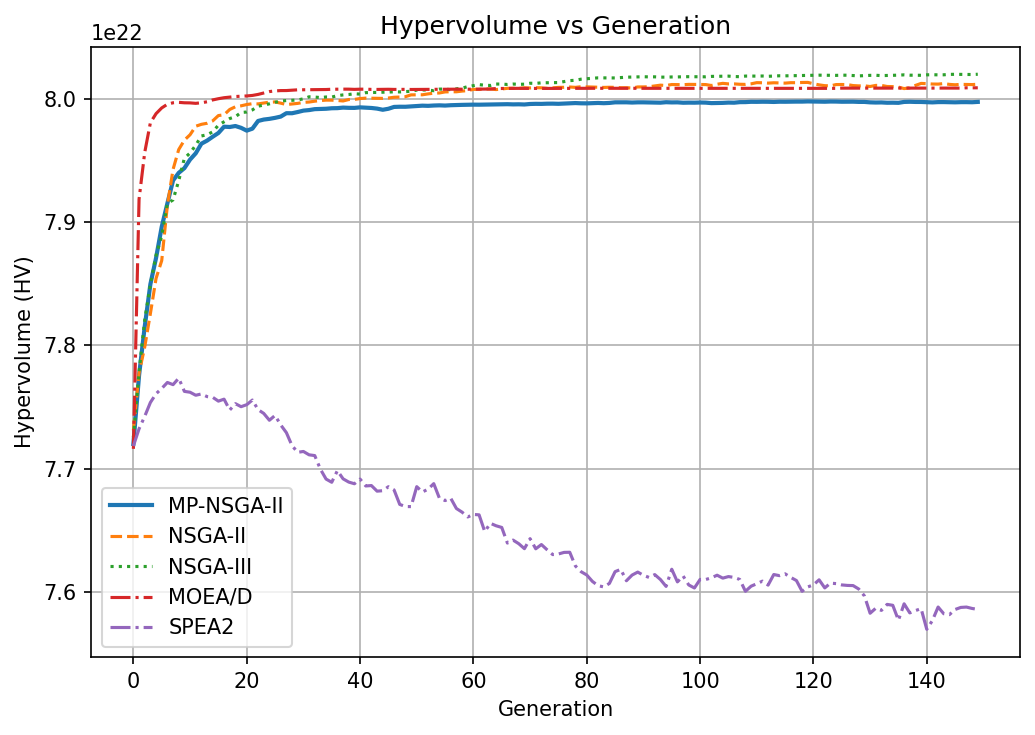

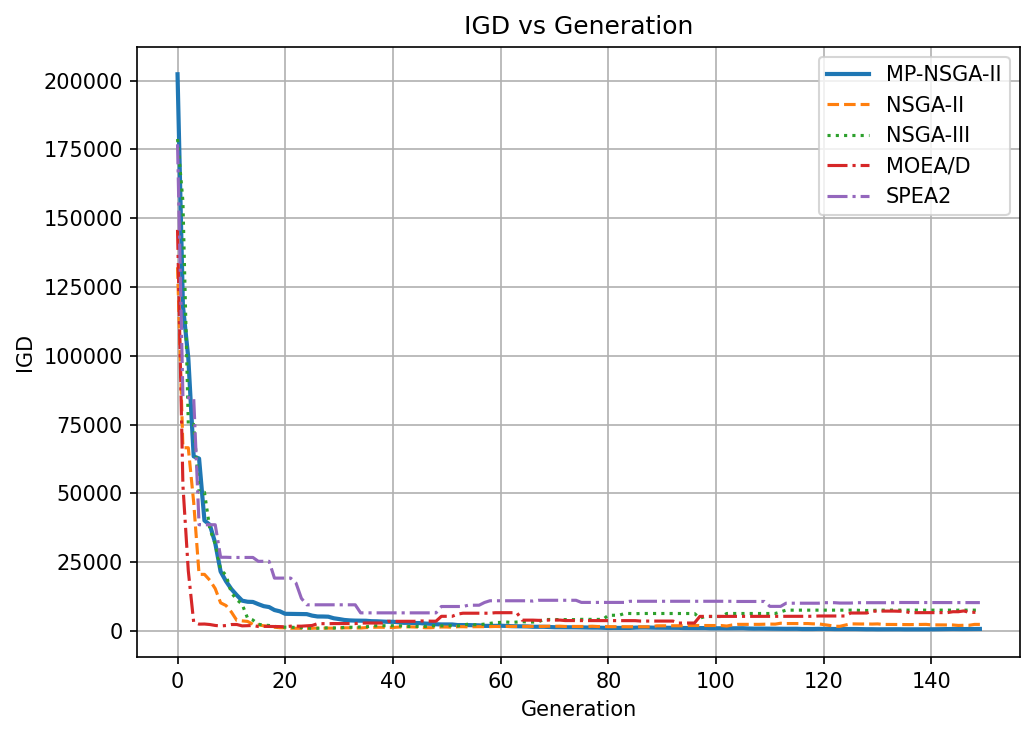


========== Algorithm Comparison Summary (5 methods) ==========

    Algorithm                             HV_mean  \
0  MP-NSGA-II 79,984,069,476,199,327,334,400.0000   
1     NSGA-II 80,116,721,444,468,559,970,304.0000   
2    NSGA-III 80,137,168,578,136,676,237,312.0000   
3      MOEA/D 80,085,130,951,408,438,214,656.0000   
4       SPEA2 75,985,722,426,840,888,377,344.0000   

                            HV_std   IGD_mean    IGD_std  Runtime_mean_sec  
0  13,102,044,359,356,985,344.0000   929.4455   212.9276           62.9550  
1  26,148,894,591,820,488,704.0000 2,290.3471   494.2674           61.7380  
2  49,292,962,789,113,094,144.0000 6,300.3704 1,053.1241           66.5179  
3  43,903,510,300,573,548,544.0000 4,488.9140 1,460.9757           19.8648  
4 106,344,558,091,933,761,536.0000 7,989.8046 2,642.4868           79.3097  

Saved: Table_Algorithm_Comparison_All_5.csv


In [ ]:
# ===============================================================
# PART 6 — Algorithm Comparison:
# MP-NSGA-II vs NSGA-II vs NSGA-III vs MOEA/D vs SPEA2
# ===============================================================

import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

# ---------------------------------------------------------------
# 0. Flat-vector encoding shared by NSGA-II / NSGA-III / MOEA/D / SPEA2
# ---------------------------------------------------------------

VAR_ORDER = [
    "price", "G", "r",
    "x_mech", "x_chem", "x_energy", "x_landfill", "x_mis",
    "P_V", "T_F", "tau"
]
N_PER_POLY = len(VAR_ORDER)
N_POLY = len(POLYMERS)
N_VAR = N_PER_POLY * N_POLY

# Precompute bounds in the same order as VAR_ORDER
VAR_LOW = []
VAR_HIGH = []
for _i in POLYMERS:
    for key in VAR_ORDER:
        lo, hi = bounds[key]
        VAR_LOW.append(lo)
        VAR_HIGH.append(hi)
VAR_LOW = np.array(VAR_LOW, dtype=float)
VAR_HIGH = np.array(VAR_HIGH, dtype=float)


def flat_to_solution(flat):
    """
    Map a flat numpy vector (length N_VAR) to the structured solution
    dictionary used by evaluate_solution().
    """
    sol = {}
    idx = 0

    for i in POLYMERS:
        price      = flat[idx]; idx += 1
        G          = flat[idx]; idx += 1
        r          = flat[idx]; idx += 1
        x_mech     = flat[idx]; idx += 1
        x_chem     = flat[idx]; idx += 1
        x_energy   = flat[idx]; idx += 1
        x_landfill = flat[idx]; idx += 1
        x_mis      = flat[idx]; idx += 1
        P_V        = flat[idx]; idx += 1
        T_F        = flat[idx]; idx += 1
        tau        = flat[idx]; idx += 1

        sol[i] = {
            "price": price,
            "G": G,
            "r": r,
            "x_mech": x_mech,
            "x_chem": x_chem,
            "x_energy": x_energy,
            "x_landfill": x_landfill,
            "x_mis": x_mis,
            "P_V": P_V,
            "T_F": T_F,
            "tau": tau,
        }

        # Normalise routing fractions so they sum to 1
        total = x_mech + x_chem + x_energy + x_landfill + x_mis
        if total <= 0:
            sol[i]["x_mech"] = 1.0
            sol[i]["x_chem"] = 0.0
            sol[i]["x_energy"] = 0.0
            sol[i]["x_landfill"] = 0.0
            sol[i]["x_mis"] = 0.0
        else:
            sol[i]["x_mech"]     /= total
            sol[i]["x_chem"]     /= total
            sol[i]["x_energy"]   /= total
            sol[i]["x_landfill"] /= total
            sol[i]["x_mis"]      /= total

    return sol


def initialize_population_flat(pop_size):
    """
    Initialise a population of flat vectors in [VAR_LOW, VAR_HIGH].
    """
    pop = []
    for _ in range(pop_size):
        x = VAR_LOW + (VAR_HIGH - VAR_LOW) * np.random.rand(N_VAR)
        pop.append(x)
    return np.array(pop)


def evaluate_population_flat(pop_flat):
    """
    Evaluate a population of flat vectors via evaluate_solution(flat_to_solution).
    Returns (N,3) objective array.
    """
    N = pop_flat.shape[0]
    objs = np.zeros((N, 3), dtype=float)
    for i in range(N):
        sol = flat_to_solution(pop_flat[i])
        objs[i, :] = evaluate_solution(sol)
    return objs


# ---------------------------------------------------------------
# 1. Shared operators for flat algorithms (NSGA-II family)
# ---------------------------------------------------------------

def tournament_select_std(objs, ranks, crowding, k=2):
    """
    Binary tournament selection on indices using (rank, crowding).
    """
    N = objs.shape[0]
    candidates = np.random.choice(N, size=k, replace=False)
    best = candidates[0]
    for c in candidates[1:]:
        if ranks[c] < ranks[best]:
            best = c
        elif ranks[c] == ranks[best]:
            if crowding[c] > crowding[best]:
                best = c
    return best


def sbx_crossover_std(p1, p2, eta_c=ETA_C, p_c=P_CROSS):
    """
    SBX crossover for flat numpy vectors.
    Returns two children.
    """
    if np.random.rand() > p_c:
        return p1.copy(), p2.copy()

    child1 = p1.copy()
    child2 = p2.copy()

    for j in range(N_VAR):
        x1 = p1[j]
        x2 = p2[j]
        xl = VAR_LOW[j]
        xu = VAR_HIGH[j]

        if np.random.rand() <= 0.5:
            if abs(x1 - x2) > 1e-14:
                if x1 > x2:
                    x1, x2 = x2, x1

                rand = np.random.rand()
                beta = 1.0 + (2.0 * (x1 - xl) / (x2 - x1))
                alpha_ = 2.0 - beta ** -(eta_c + 1.0)

                if rand <= 1.0 / alpha_:
                    betaq = (rand * alpha_) ** (1.0 / (eta_c + 1.0))
                else:
                    betaq = (1.0 / (2.0 - rand * alpha_)) ** (1.0 / (eta_c + 1.0))

                c1 = 0.5 * ((x1 + x2) - betaq * (x2 - x1))
                c2 = 0.5 * ((x1 + x2) + betaq * (x2 - x1))

                c1 = np.clip(c1, xl, xu)
                c2 = np.clip(c2, xl, xu)

                child1[j] = c1
                child2[j] = c2
            else:
                child1[j] = x1
                child2[j] = x2

    return child1, child2


def gaussian_mutation_std(x, p_mut=0.1, sigma_frac=0.1):
    """
    Simple Gaussian mutation with per-variable probability p_mut.
    """
    y = x.copy()
    for j in range(N_VAR):
        if np.random.rand() < p_mut:
            lo = VAR_LOW[j]
            hi = VAR_HIGH[j]
            sigma = sigma_frac * (hi - lo)
            y[j] += np.random.normal(0.0, sigma)
            y[j] = np.clip(y[j], lo, hi)
    return y


def nd_selection_std(pop, objs, pop_size):
    """
    Standard NSGA-II environmental selection on flat vectors.
    Uses fast_non_dominated_sort and crowding_distance from earlier parts.
    """
    fronts = fast_non_dominated_sort(objs)
    new_pop = []
    new_objs = []

    for front in fronts:
        if len(new_pop) + len(front) > pop_size:
            distances = crowding_distance(objs, front)
            sorted_front = sorted(front, key=lambda idx: distances[idx], reverse=True)
            remaining = pop_size - len(new_pop)
            chosen = sorted_front[:remaining]
        else:
            chosen = front

        for idx in chosen:
            new_pop.append(pop[idx])
            new_objs.append(objs[idx])

        if len(new_pop) == pop_size:
            break

    return np.array(new_pop), np.vstack(new_objs)


# ---------------------------------------------------------------
# 2. Hypervolume & IGD utilities (shared across all algorithms)
# ---------------------------------------------------------------
pareto_reference_front = pareto.copy()  # MP-NSGA-II Pareto from Part 5


def compute_hypervolume(objs, ref_point):
    """
    Very simple HV: sum of positive (ref - point) box volumes.
    """
    diff = ref_point - objs
    vol = np.prod(diff, axis=1)
    vol = vol[vol > 0]
    return vol.sum()


def compute_igd(objs, reference):
    """
    IGD = average distance from each reference point to nearest solution.
    """
    total = 0.0
    for r in reference:
        d = np.linalg.norm(objs - r, axis=1)
        total += d.min()
    return total / len(reference)


# ---------------------------------------------------------------
# 3. STANDARD NSGA-II (flat)
# ---------------------------------------------------------------
def run_standard_nsga2(n_gen, pop_size, verbose=False):
    """
    Standard NSGA-II:
      - Flattened decision vectors
      - SBX crossover
      - Gaussian mutation
      - Classical NSGA-II selection
    Returns pop, objs, history dict with hv & igd.
    """
    pop = initialize_population_flat(pop_size)
    objs = evaluate_population_flat(pop)

    history = {"hv": [], "igd": []}
    ref_point = np.array([1e7, 1e7, 1e7], dtype=float)

    for g in range(n_gen):
        # Record metrics
        hv = compute_hypervolume(objs, ref_point)
        igd = compute_igd(objs, pareto_reference_front)
        history["hv"].append(hv)
        history["igd"].append(igd)

        # Non-dominated sorting & crowding for selection
        fronts = fast_non_dominated_sort(objs)
        ranks = np.zeros(pop.shape[0], dtype=int)
        crowd = np.zeros(pop.shape[0], dtype=float)
        for f_idx, front in enumerate(fronts):
            for idx in front:
                ranks[idx] = f_idx
            dist = crowding_distance(objs, front)
            for idx, d in dist.items():
                crowd[idx] = d

        # Mating pool (indices)
        mating_idx = []
        while len(mating_idx) < pop_size:
            sel = tournament_select_std(objs, ranks, crowd, k=2)
            mating_idx.append(sel)

        # Variation
        children = []
        for j in range(0, pop_size, 2):
            p1 = pop[mating_idx[j]]
            p2 = pop[mating_idx[(j + 1) % pop_size]]
            c1, c2 = sbx_crossover_std(p1, p2)
            c1 = gaussian_mutation_std(c1, p_mut=0.1)
            c2 = gaussian_mutation_std(c2, p_mut=0.1)
            children.append(c1)
            children.append(c2)

        children = np.array(children[:pop_size])
        child_objs = evaluate_population_flat(children)

        # Environmental selection on combined
        combined_pop = np.vstack([pop, children])
        combined_objs = np.vstack([objs, child_objs])
        pop, objs = nd_selection_std(combined_pop, combined_objs, pop_size)

        if verbose and (g % 10 == 0 or g == n_gen - 1):
            print(f"[Std NSGA-II] Gen {g:4d} | HV={hv:.2e}, IGD={igd:.2f}")

    return pop, objs, history


# ---------------------------------------------------------------
# 4. NSGA-III (flat, reference-direction niching)
# ---------------------------------------------------------------

def generate_reference_directions(M=3, p=12):
    """
    Generate reference directions on the unit simplex (NSGA-III style).
    For M=3, we generate integer triples (a,b,c) s.t. a+b+c=p.
    """
    dirs = []
    for a in range(p + 1):
        for b in range(p + 1 - a):
            c = p - a - b
            v = np.array([a, b, c], dtype=float)
            if np.linalg.norm(v) > 0:
                v /= np.linalg.norm(v)
                dirs.append(v)
    return np.array(dirs)


REF_DIRS = generate_reference_directions(M=3, p=12)


def normalize_objectives(objs):
    """
    Normalise objectives for NSGA-III selection.
    """
    zmin = objs.min(axis=0)
    zmax = objs.max(axis=0)
    denom = zmax - zmin
    denom[denom == 0] = 1.0
    return (objs - zmin) / denom, zmin, zmax


def assign_to_reference_points(objs_norm, ref_dirs):
    """
    For each solution, compute perpendicular distance to each reference direction
    and assign to the closest one.
    """
    N = objs_norm.shape[0]
    K = ref_dirs.shape[0]
    assoc = np.zeros(N, dtype=int)
    distances = np.zeros(N, dtype=float)

    for i in range(N):
        y = objs_norm[i]
        # Distance to line spanned by ref_dir: ||y|| * sin(theta)
        # Equivalent: sqrt(||y||^2 - (y·w)^2)
        normsqr = np.dot(y, y)
        best_k = 0
        best_d = np.inf
        for k in range(K):
            w = ref_dirs[k]
            proj = np.dot(y, w)
            d = np.sqrt(max(normsqr - proj ** 2, 0.0))
            if d < best_d:
                best_d = d
                best_k = k
        assoc[i] = best_k
        distances[i] = best_d

    return assoc, distances


def nsga3_environmental_selection(pop, objs, pop_size, ref_dirs):
    """
    Environmental selection for NSGA-III with reference-direction niching.
    """
    fronts = fast_non_dominated_sort(objs)
    new_pop = []
    new_objs = []

    for front in fronts:
        if len(new_pop) + len(front) < pop_size:
            # Add entire front
            for idx in front:
                new_pop.append(pop[idx])
                new_objs.append(objs[idx])
        else:
            # Need partial front selection using NSGA-III niching
            remaining = pop_size - len(new_pop)
            front_indices = np.array(front, dtype=int)

            # Normalise entire population (as per NSGA-III)
            objs_norm, _, _ = normalize_objectives(objs)
            objs_f_norm = objs_norm[front_indices]

            assoc, dist = assign_to_reference_points(objs_f_norm, ref_dirs)

            # Count how many have already been assigned in previous fronts
            # For simplicity, treat already selected as "occupied"
            selected_indices = np.array([i for i in range(len(new_pop))])
            if selected_indices.size > 0:
                sel_norm = objs_norm[selected_indices]
                sel_assoc, _ = assign_to_reference_points(sel_norm, ref_dirs)
                niche_count = np.zeros(ref_dirs.shape[0], dtype=int)
                for a in sel_assoc:
                    niche_count[a] += 1
            else:
                niche_count = np.zeros(ref_dirs.shape[0], dtype=int)

            # Candidates per niche
            niche_to_candidates = {}
            for local_idx, global_idx in enumerate(front_indices):
                niche = assoc[local_idx]
                if niche not in niche_to_candidates:
                    niche_to_candidates[niche] = []
                niche_to_candidates[niche].append((global_idx, dist[local_idx]))

            chosen = []
            while len(chosen) < remaining:
                # Pick least crowded niche
                niche = np.argmin(niche_count)
                if niche not in niche_to_candidates or len(niche_to_candidates[niche]) == 0:
                    # If no candidate, mark niche as full and continue
                    niche_count[niche] = 10**9
                    if (niche_count == 10**9).all():
                        break
                    continue

                # Within this niche, pick candidate with smallest distance
                cand_list = niche_to_candidates[niche]
                cand_list.sort(key=lambda x: x[1])  # sort by dist
                pick_idx, pick_d = cand_list.pop(0)
                chosen.append(pick_idx)
                niche_count[niche] += 1

            for idx in chosen:
                new_pop.append(pop[idx])
                new_objs.append(objs[idx])

        if len(new_pop) >= pop_size:
            break

    return np.array(new_pop), np.vstack(new_objs)


def run_nsga3(n_gen, pop_size, verbose=False):
    """
    NSGA-III on flat encoding with reference-direction niching.
    """
    pop = initialize_population_flat(pop_size)
    objs = evaluate_population_flat(pop)

    history = {"hv": [], "igd": []}
    ref_point = np.array([1e7, 1e7, 1e7], dtype=float)

    for g in range(n_gen):
        hv = compute_hypervolume(objs, ref_point)
        igd = compute_igd(objs, pareto_reference_front)
        history["hv"].append(hv)
        history["igd"].append(igd)

        # Fast ND sorting for ranks (used to identify fronts)
        fronts = fast_non_dominated_sort(objs)

        if verbose and (g % 10 == 0 or g == n_gen - 1):
            print(f"[NSGA-III] Gen {g:4d} | HV={hv:.2e}, IGD={igd:.2f}")

        # Mating pool: binary tournament on rank + simple crowding
        ranks = np.zeros(pop.shape[0], dtype=int)
        crowd = np.zeros(pop.shape[0], dtype=float)
        for f_idx, front in enumerate(fronts):
            for idx in front:
                ranks[idx] = f_idx
            dist = crowding_distance(objs, front)
            for idx, d in dist.items():
                crowd[idx] = d

        mating_idx = []
        while len(mating_idx) < pop_size:
            sel = tournament_select_std(objs, ranks, crowd, k=2)
            mating_idx.append(sel)

        # Variation
        children = []
        for j in range(0, pop_size, 2):
            p1 = pop[mating_idx[j]]
            p2 = pop[mating_idx[(j + 1) % pop_size]]
            c1, c2 = sbx_crossover_std(p1, p2)
            c1 = gaussian_mutation_std(c1, p_mut=0.1)
            c2 = gaussian_mutation_std(c2, p_mut=0.1)
            children.append(c1)
            children.append(c2)

        children = np.array(children[:pop_size])
        child_objs = evaluate_population_flat(children)

        combined_pop = np.vstack([pop, children])
        combined_objs = np.vstack([objs, child_objs])

        pop, objs = nsga3_environmental_selection(combined_pop, combined_objs, pop_size, REF_DIRS)

    return pop, objs, history


# ---------------------------------------------------------------
# 5. MOEA/D (flat, Tchebycheff decomposition)
# ---------------------------------------------------------------

def generate_weight_vectors(M=3, p=12):
    """Same as reference directions, but used as MOEA/D weights."""
    return generate_reference_directions(M, p)


MOEAD_WEIGHTS = generate_weight_vectors(M=3, p=12)
MOEAD_POP_SIZE = MOEAD_WEIGHTS.shape[0]


def moead_tchebycheff(f, w, z):
    """
    Tchebycheff scalarization.
    f: objective vector
    w: weight vector
    z: ideal point
    """
    return np.max(w * np.abs(f - z))


def run_moead(n_gen, pop_size=None, T=10, verbose=False):
    """
    MOEA/D with Tchebycheff decomposition on flat encoding.
    pop_size defaults to number of weight vectors.
    """
    if pop_size is None:
        pop_size = MOEAD_POP_SIZE
    # Make sure pop_size <= number of weight vectors
    pop_size = min(pop_size, MOEAD_POP_SIZE)
    W = MOEAD_WEIGHTS[:pop_size]

    # Precompute neighborhoods based on Euclidean distance between weights
    dist_w = np.linalg.norm(W[:, None, :] - W[None, :, :], axis=2)
    B = np.argsort(dist_w, axis=1)[:, :T]

    # Initialise population
    pop = initialize_population_flat(pop_size)
    objs = evaluate_population_flat(pop)

    # Ideal point
    z = objs.min(axis=0)

    history = {"hv": [], "igd": []}
    ref_point = np.array([1e7, 1e7, 1e7], dtype=float)

    for g in range(n_gen):
        hv = compute_hypervolume(objs, ref_point)
        igd = compute_igd(objs, pareto_reference_front)
        history["hv"].append(hv)
        history["igd"].append(igd)

        if verbose and (g % 10 == 0 or g == n_gen - 1):
            print(f"[MOEA/D] Gen {g:4d} | HV={hv:.2e}, IGD={igd:.2f}")

        for i in range(pop_size):
            # Parents from neighborhood
            neighbors = B[i]
            p1, p2 = np.random.choice(neighbors, size=2, replace=False)
            c1, c2 = sbx_crossover_std(pop[p1], pop[p2])
            child = gaussian_mutation_std(c1, p_mut=0.1)
            f_child = evaluate_population_flat(child.reshape(1, -1))[0]

            # Update ideal point
            z = np.minimum(z, f_child)

            # Update neighborhood solutions
            for j in neighbors:
                f_old = objs[j]
                g_old = moead_tchebycheff(f_old, W[j], z)
                g_new = moead_tchebycheff(f_child, W[j], z)
                if g_new <= g_old:
                    pop[j] = child
                    objs[j] = f_child

    return pop, objs, history


# ---------------------------------------------------------------
# 6. SPEA2 (flat)
# ---------------------------------------------------------------

def compute_spea2_fitness(objs):
    """
    Compute SPEA2 fitness values.
    objs: (N, M) objective matrix.
    Returns:
      F: fitness array (lower is better)
    """
    N = objs.shape[0]
    # Strength S(i): number of solutions it dominates
    S = np.zeros(N, dtype=float)
    # Raw fitness R(i): sum of strengths of solutions that dominate i
    R = np.zeros(N, dtype=float)

    # Dominance matrix
    for i in range(N):
        for j in range(N):
            if i == j:
                continue
            # i dominates j?
            if np.all(objs[i] <= objs[j]) and np.any(objs[i] < objs[j]):
                S[i] += 1.0

    for i in range(N):
        for j in range(N):
            if i == j:
                continue
            # j dominates i?
            if np.all(objs[j] <= objs[i]) and np.any(objs[j] < objs[i]):
                R[i] += S[j]

    # Density term D(i)
    # k = sqrt(N) nearest neighbors (SPEA2 suggestion)
    k = max(1, int(np.sqrt(N)))
    D = np.zeros(N, dtype=float)
    dist_matrix = np.linalg.norm(objs[:, None, :] - objs[None, :, :], axis=2)
    # sort each row, ignore self distance = 0
    for i in range(N):
        d_sorted = np.sort(dist_matrix[i])
        # nearest non-zero distance at index 1, but we use k-th neighbor
        idx = min(k, N - 1)
        sigma_k = d_sorted[idx]
        D[i] = 1.0 / (sigma_k + 2.0)

    F = R + D
    return F


def spea2_truncate(archive_pop, archive_objs, N):
    """
    Truncation operator for SPEA2 when archive size > N.
    """
    pop = list(archive_pop)
    objs = list(archive_objs)
    while len(pop) > N:
        objs_array = np.array(objs)
        dist = np.linalg.norm(objs_array[:, None, :] - objs_array[None, :, :], axis=2)
        np.fill_diagonal(dist, np.inf)

        # find pair with minimum distance
        i_min, j_min = np.unravel_index(np.argmin(dist), dist.shape)
        # remove one of them (e.g., j_min)
        pop.pop(j_min)
        objs.pop(j_min)
    return np.array(pop), np.array(objs)


def run_spea2(n_gen, pop_size, verbose=False):
    """
    SPEA2 on flat encoding.
    """
    # Initial population
    pop = initialize_population_flat(pop_size)
    objs = evaluate_population_flat(pop)

    # Archive
    archive_pop = np.empty((0, N_VAR), dtype=float)
    archive_objs = np.empty((0, 3), dtype=float)

    history = {"hv": [], "igd": []}
    ref_point = np.array([1e7, 1e7, 1e7], dtype=float)

    for g in range(n_gen):
        # Combine population and archive
        combined_pop = np.vstack([archive_pop, pop])
        combined_objs = np.vstack([archive_objs, objs])

        # Compute SPEA2 fitness
        F = compute_spea2_fitness(combined_objs)

        # Environmental selection to build new archive
        idx_sorted = np.argsort(F)
        new_archive_pop = combined_pop[idx_sorted]
        new_archive_objs = combined_objs[idx_sorted]

        if new_archive_pop.shape[0] > pop_size:
            archive_pop, archive_objs = spea2_truncate(new_archive_pop, new_archive_objs, pop_size)
        else:
            archive_pop = new_archive_pop
            archive_objs = new_archive_objs

        # Record metrics using archive (as final set)
        hv = compute_hypervolume(archive_objs, ref_point)
        igd = compute_igd(archive_objs, pareto_reference_front)
        history["hv"].append(hv)
        history["igd"].append(igd)

        if verbose and (g % 10 == 0 or g == n_gen - 1):
            print(f"[SPEA2] Gen {g:4d} | HV={hv:.2e}, IGD={igd:.2f}")

        # If archive has fewer than 2 pop_size, refill a bit
        if archive_pop.shape[0] < pop_size:
            extra = pop_size - archive_pop.shape[0]
            extra_pop = initialize_population_flat(extra)
            extra_objs = evaluate_population_flat(extra_pop)
            archive_pop = np.vstack([archive_pop, extra_pop])
            archive_objs = np.vstack([archive_objs, extra_objs])

        # Mating pool from archive (binary tournament on fitness F)
        # Recompute fitness for archive only
        F_archive = compute_spea2_fitness(archive_objs)
        mating_idx = []
        A = archive_pop.shape[0]
        while len(mating_idx) < pop_size:
            i1, i2 = np.random.choice(A, size=2, replace=False)
            if F_archive[i1] < F_archive[i2]:
                mating_idx.append(i1)
            else:
                mating_idx.append(i2)

        # Variation to produce next generation population
        children = []
        for j in range(0, pop_size, 2):
            p1 = archive_pop[mating_idx[j]]
            p2 = archive_pop[mating_idx[(j + 1) % pop_size]]
            c1, c2 = sbx_crossover_std(p1, p2)
            c1 = gaussian_mutation_std(c1, p_mut=0.1)
            c2 = gaussian_mutation_std(c2, p_mut=0.1)
            children.append(c1)
            children.append(c2)
        pop = np.array(children[:pop_size])
        objs = evaluate_population_flat(pop)

    # Final output is archive
    return archive_pop, archive_objs, history


# ---------------------------------------------------------------
# 7. MP-NSGA-II wrapper (polymer-aware, from your Part 4)
# ---------------------------------------------------------------
def run_mp_nsga2_with_metrics(n_gen, pop_size, verbose=False):
    """
    Wrapper around your existing MP-NSGA-II (make_next_generation, etc.)
    to also track HV & IGD.
    """
    pop = [initialize_solution() for _ in range(pop_size)]
    objs = evaluate_population(pop)

    history = {"hv": [], "igd": []}
    ref_point = np.array([1e7, 1e7, 1e7], dtype=float)

    for g in range(n_gen):
        hv = compute_hypervolume(objs, ref_point)
        igd = compute_igd(objs, pareto_reference_front)
        history["hv"].append(hv)
        history["igd"].append(igd)

        if verbose and (g % 10 == 0 or g == n_gen - 1):
            print(
                f"[MP-NSGA-II] Gen {g:4d} | "
                f"HV={hv:.2e}, IGD={igd:.2f}, "
                f"minC={objs[:,0].min():.2f}, minE={objs[:,1].min():.2f}, minM={objs[:,2].min():.2f}"
            )

        pop, objs = make_next_generation(pop, objs)

    return pop, objs, history


# ---------------------------------------------------------------
# 8. Run all five algorithms multiple times + summary metrics
# ---------------------------------------------------------------
N_RUNS = 3  # you can increase to 5 or 10 later

metrics = {
    "mp_hv": [], "mp_igd": [], "mp_time": [],
    "ns2_hv": [], "ns2_igd": [], "ns2_time": [],
    "ns3_hv": [], "ns3_igd": [], "ns3_time": [],
    "moead_hv": [], "moead_igd": [], "moead_time": [],
    "spea2_hv": [], "spea2_igd": [], "spea2_time": [],
}

print("\n========== Running Algorithm Comparison (5 methods) ==========\n")

mp_hist_last = None
ns2_hist_last = None
ns3_hist_last = None
moead_hist_last = None
spea2_hist_last = None

for run in range(N_RUNS):
    print(f"\n--- Run {run + 1}/{N_RUNS} ---")

    # MP-NSGA-II
    t0 = time.time()
    mp_pop, mp_objs, mp_hist = run_mp_nsga2_with_metrics(N_GEN, POP_SIZE, verbose=False)
    t1 = time.time()
    mp_time = t1 - t0
    mp_hv_final = compute_hypervolume(mp_objs, np.array([1e7, 1e7, 1e7]))
    mp_igd_final = compute_igd(mp_objs, pareto_reference_front)

    metrics["mp_hv"].append(mp_hv_final)
    metrics["mp_igd"].append(mp_igd_final)
    metrics["mp_time"].append(mp_time)
    mp_hist_last = mp_hist

    # Standard NSGA-II
    t0 = time.time()
    ns2_pop, ns2_objs, ns2_hist = run_standard_nsga2(N_GEN, POP_SIZE, verbose=False)
    t1 = time.time()
    ns2_time = t1 - t0
    ns2_hv_final = compute_hypervolume(ns2_objs, np.array([1e7, 1e7, 1e7]))
    ns2_igd_final = compute_igd(ns2_objs, pareto_reference_front)

    metrics["ns2_hv"].append(ns2_hv_final)
    metrics["ns2_igd"].append(ns2_igd_final)
    metrics["ns2_time"].append(ns2_time)
    ns2_hist_last = ns2_hist

    # NSGA-III
    t0 = time.time()
    ns3_pop, ns3_objs, ns3_hist = run_nsga3(N_GEN, POP_SIZE, verbose=False)
    t1 = time.time()
    ns3_time = t1 - t0
    ns3_hv_final = compute_hypervolume(ns3_objs, np.array([1e7, 1e7, 1e7]))
    ns3_igd_final = compute_igd(ns3_objs, pareto_reference_front)

    metrics["ns3_hv"].append(ns3_hv_final)
    metrics["ns3_igd"].append(ns3_igd_final)
    metrics["ns3_time"].append(ns3_time)
    ns3_hist_last = ns3_hist

    # MOEA/D
    t0 = time.time()
    moead_pop, moead_objs, moead_hist = run_moead(N_GEN, POP_SIZE, verbose=False)
    t1 = time.time()
    moead_time = t1 - t0
    moead_hv_final = compute_hypervolume(moead_objs, np.array([1e7, 1e7, 1e7]))
    moead_igd_final = compute_igd(moead_objs, pareto_reference_front)

    metrics["moead_hv"].append(moead_hv_final)
    metrics["moead_igd"].append(moead_igd_final)
    metrics["moead_time"].append(moead_time)
    moead_hist_last = moead_hist

    # SPEA2
    t0 = time.time()
    spea2_pop, spea2_objs, spea2_hist = run_spea2(N_GEN, POP_SIZE, verbose=False)
    t1 = time.time()
    spea2_time = t1 - t0
    spea2_hv_final = compute_hypervolume(spea2_objs, np.array([1e7, 1e7, 1e7]))
    spea2_igd_final = compute_igd(spea2_objs, pareto_reference_front)

    metrics["spea2_hv"].append(spea2_hv_final)
    metrics["spea2_igd"].append(spea2_igd_final)
    metrics["spea2_time"].append(spea2_time)
    spea2_hist_last = spea2_hist

print("\nCompleted all runs for all algorithms.\n")


# ---------------------------------------------------------------
# 9. Plot HV and IGD vs Generation (using last run)
# ---------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(mp_hist_last["hv"],   label="MP-NSGA-II", linewidth=2)
plt.plot(ns2_hist_last["hv"],  label="NSGA-II",    linestyle="--")
plt.plot(ns3_hist_last["hv"],  label="NSGA-III",   linestyle=":")
plt.plot(moead_hist_last["hv"], label="MOEA/D",    linestyle="-.")
plt.plot(spea2_hist_last["hv"], label="SPEA2",     linestyle="-.")

plt.xlabel("Generation")
plt.ylabel("Hypervolume (HV)")
plt.title("Hypervolume vs Generation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Fig6a_HV_vs_Gen_All.png")
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(mp_hist_last["igd"],   label="MP-NSGA-II", linewidth=2)
plt.plot(ns2_hist_last["igd"],  label="NSGA-II",    linestyle="--")
plt.plot(ns3_hist_last["igd"],  label="NSGA-III",   linestyle=":")
plt.plot(moead_hist_last["igd"], label="MOEA/D",    linestyle="-.")
plt.plot(spea2_hist_last["igd"], label="SPEA2",     linestyle="-.")

plt.xlabel("Generation")
plt.ylabel("IGD")
plt.title("IGD vs Generation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Fig6b_IGD_vs_Gen_All.png")
plt.show()



# ---------------------------------------------------------------
# 10. Summary Table (Mean ± std over runs)
# ---------------------------------------------------------------
summary_df = pd.DataFrame({
    "Algorithm": [
        "MP-NSGA-II",
        "NSGA-II",
        "NSGA-III",
        "MOEA/D",
        "SPEA2"
    ],
    "HV_mean": [
        np.mean(metrics["mp_hv"]),
        np.mean(metrics["ns2_hv"]),
        np.mean(metrics["ns3_hv"]),
        np.mean(metrics["moead_hv"]),
        np.mean(metrics["spea2_hv"]),
    ],
    "HV_std": [
        np.std(metrics["mp_hv"]),
        np.std(metrics["ns2_hv"]),
        np.std(metrics["ns3_hv"]),
        np.std(metrics["moead_hv"]),
        np.std(metrics["spea2_hv"]),
    ],
    "IGD_mean": [
        np.mean(metrics["mp_igd"]),
        np.mean(metrics["ns2_igd"]),
        np.mean(metrics["ns3_igd"]),
        np.mean(metrics["moead_igd"]),
        np.mean(metrics["spea2_igd"]),
    ],
    "IGD_std": [
        np.std(metrics["mp_igd"]),
        np.std(metrics["ns2_igd"]),
        np.std(metrics["ns3_igd"]),
        np.std(metrics["moead_igd"]),
        np.std(metrics["spea2_igd"]),
    ],
    "Runtime_mean_sec": [
        np.mean(metrics["mp_time"]),
        np.mean(metrics["ns2_time"]),
        np.mean(metrics["ns3_time"]),
        np.mean(metrics["moead_time"]),
        np.mean(metrics["spea2_time"]),
    ]
})

print("\n========== Algorithm Comparison Summary (5 methods) ==========\n")
print(summary_df)

summary_df.to_csv("Table_Algorithm_Comparison_All_5.csv", index=False)
print("\nSaved: Table_Algorithm_Comparison_All_5.csv")
